In [1]:
# ============================================================
# Scenario information (inserted automatically)
# ============================================================
SCENARIO_NUMBER = 13
SCENARIO_NAME = 'Very high makespan pressure'
SCENARIO_C_DOWN_STEP = 0.05
SCENARIO_C_LANE = 100
SCENARIO_C_GRADER = 500
SCENARIO_C_MAKE = 50
SCENARIO_C_PEN_MULTIPLIER = 0.2
SCENARIO_ACTUAL_UNMET_DEMAND_PENALTY = 2

print(f"Running scenario {SCENARIO_NUMBER:02d}: {SCENARIO_NAME}")
print(f"Actual unmet-demand penalty: {SCENARIO_ACTUAL_UNMET_DEMAND_PENALTY}")


Running scenario 13: Very high makespan pressure
Actual unmet-demand penalty: 2


In [2]:
# ============================================================
# User settings
# ============================================================

TARGET_DATE = "2026-06-18"

# Treat only completed orders as actually done.
INCLUDE_STATUSES = {"completed"}

# Demand quantity rule
USE_PRODUCED_QUANTITY_IF_AVAILABLE = False

# Contract minimum demand rule
MIN_DEMAND_FRACTION = 0.60

# Default values for fields not available in the JSON
DEFAULT_PRINTING_REQUIREMENT = 0
DEFAULT_UNMET_DEMAND_PENALTY = 2

# Stable machine settings
NUM_LANES = 18
C_lane = 1250
C_grader = 25000

# Planning horizon.

T = list(range(1, 97))  # 96 time periods
T_end = list(range(1, 97))




# ============================================================
# Read supplier count CSV
# ============================================================
# S B S(BK)

import pandas as pd
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
from itertools import product
import time

supplier_file = Path("SupplierCountResults18June2026.csv")

supplier_raw = pd.read_csv(
    supplier_file,
    na_values=["NULL"]
)

# Parse date columns where available
date_columns = [
    "StiCreatedDate",
    "StiModifiedDate",
    "HscStartDate",
    "HscEndDate",
]

for col in date_columns:
    if col in supplier_raw.columns:
        supplier_raw[col] = pd.to_datetime(
            supplier_raw[col],
            errors="coerce"
        )

print("Supplier count file loaded.")
print(f"Rows:    {len(supplier_raw):,}")
print(f"Columns: {len(supplier_raw.columns):,}")
print(f"File:    {supplier_file}")


# ============================================================
# Aggregate raw supplier names into canonical supplier groups
# ============================================================

CANONICAL_SUPPLIERS = [
    "Farm Kelbra",
    "Geflügel Siemers Steinfel",
    "Geflügelfarm Welbsleben",
    "Hühnerhof Lohse",
    "Hühnerhof Quenstedt",
    "Hühnerhof Steuden",
    "Rainer Becker",
]

# Optional aliases make the matching a little more robust. (ChatGPT code!)
SUPPLIER_ALIASES = {
    "Farm Kelbra": [
        "Farm Kelbra",
    ],
    "Geflügel Siemers Steinfel": [
        "Geflügel Siemers Steinfel",
        "Gefluegel Siemers Steinfel",
    ],
    "Geflügelfarm Welbsleben": [
        "Geflügelfarm Welbsleben",
        "Gefluegelfarm Welbsleben",
    ],
    "Hühnerhof Lohse": [
        "Hühnerhof Lohse",
        "Huehnerhof Lohse",
    ],
    "Hühnerhof Quenstedt": [
        "Hühnerhof Quenstedt",
        "Huehnerhof Quenstedt",
    ],
    "Hühnerhof Steuden": [
        "Hühnerhof Steuden",
        "Huehnerhof Steuden",
    ],
    "Rainer Becker": [
        "Rainer Becker",
    ],
}


def map_to_supplier_group(raw_supplier_name):
    """
    Map the raw supplier/barn name from the CSV to one canonical supplier group.
    Raises an error if no match or multiple matches are found.
    """
    if pd.isna(raw_supplier_name):
        return None

    text = str(raw_supplier_name).casefold()

    matches = []

    for canonical_supplier, aliases in SUPPLIER_ALIASES.items():
        for alias in aliases:
            if alias.casefold() in text:
                matches.append(canonical_supplier)
                break

    matches = list(dict.fromkeys(matches))  # remove duplicates while preserving order

    if len(matches) == 1:
        return matches[0]

    if len(matches) == 0:
        return None

    raise ValueError(
        f"Ambiguous supplier mapping for raw supplier name "
        f"'{raw_supplier_name}'. Matches found: {matches}"
    )


supplier_raw["SupplierGroup"] = supplier_raw["StiSupplierName"].apply(
    map_to_supplier_group
)


# ------------------------------------------------------------
# Validate supplier mapping
# ------------------------------------------------------------

unmapped_suppliers = (
    supplier_raw.loc[
        supplier_raw["SupplierGroup"].isna(),
        "StiSupplierName"
    ]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

if unmapped_suppliers:
    raise ValueError(
        "Some supplier names could not be mapped to a canonical supplier group:\n"
        + "\n".join(f"- {supplier}" for supplier in unmapped_suppliers)
    )

invalid_supplier_groups = sorted(
    set(supplier_raw["SupplierGroup"].dropna()) - set(CANONICAL_SUPPLIERS)
)

if invalid_supplier_groups:
    raise ValueError(
        "Invalid supplier groups found:\n"
        + "\n".join(f"- {supplier}" for supplier in invalid_supplier_groups)
    )


# ------------------------------------------------------------
# Show raw-to-canonical mapping
# ------------------------------------------------------------

supplier_mapping_overview = (
    supplier_raw[["StiSupplierName", "SupplierGroup"]]
    .drop_duplicates()
    .sort_values(["SupplierGroup", "StiSupplierName"])
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("SUPPLIER MAPPING OVERVIEW")
print("=" * 80)

try:
    from IPython.display import display
    display(supplier_mapping_overview)
except Exception:
    print(supplier_mapping_overview.to_string(index=False))




# ============================================================
# Transform supplier count data into model supply input
# ============================================================

# Use HsdCount/HsdGradeName as the main grading result.

COUNT_COLUMN = "HsdCount"
GRADE_COLUMN = "HsdGradeName"

# Map supplier-count grades to the quality classes used in the model.
# The file does not contain all 9 size classes, so missing classes receive zero supply.
CSV_GRADE_TO_MODEL_SIZE = {
    "Small": "S",
    "Medi":  "M",
    "Large": "L",
    "XLarg": "XL",
    "XXL":   "XXL",
}

DEFECT_GRADES = [
    "Reject",
    "Crack",
    "Dirt",
    "Leakr",
    "Blood",
]

# Use compact real data size classes.
# These match the new JSON _size entries better than the old 9 fictitious classes.
K = ["S", "M", "L", "XL", "XXL"]

# ============================================================
# Create model batches aggregated by raw supplier name
# ============================================================
# One model batch per raw supplier name, not per StiId.
# Multiple pallets / stock items with different StiIds can therefore belong
# to the same model batch.
# ============================================================

# ------------------------------------------------------------
# Validate that raw supplier names are available
# ------------------------------------------------------------

if "StiSupplierName" not in supplier_raw.columns:
    raise ValueError("CSV is missing column 'StiSupplierName'.")

missing_raw_supplier_rows = supplier_raw[
    supplier_raw["StiSupplierName"].isna()
]

if len(missing_raw_supplier_rows) > 0:
    raise ValueError(
        f"{len(missing_raw_supplier_rows)} rows have missing StiSupplierName."
    )


# ------------------------------------------------------------
# Helper for compact metadata strings
# ------------------------------------------------------------

def unique_join(values):
    cleaned = [
        str(v)
        for v in values
        if pd.notna(v)
    ]

    return ", ".join(sorted(set(cleaned)))


# ------------------------------------------------------------
# Create one batch row per raw supplier name
# ------------------------------------------------------------

supplier_batches = (
    supplier_raw
    .groupby("StiSupplierName", as_index=False)
    .agg(
        SupplierGroup=("SupplierGroup", lambda x: unique_join(x)),
        StiIds=("StiId", unique_join),
        StiNumbers=("StiNumber", unique_join),
        StiDescriptions=("StiDescription", unique_join),
        StiSupplierNumbers=("StiSupplierNumber", unique_join),
        SuiIds=("SuiId", unique_join),
        SuiNames=("SuiName", unique_join),
        HscStartDate=("HscStartDate", "min"),
        HscEndDate=("HscEndDate", "max"),
    )
    .sort_values("StiSupplierName")
    .reset_index(drop=True)
)

B = [
    f"B{i+1}"
    for i in range(len(supplier_batches))
]

raw_supplier_to_batch = {
    row["StiSupplierName"]: B[i]
    for i, row in supplier_batches.iterrows()
}

batch_to_raw_supplier = {
    b: raw_supplier
    for raw_supplier, b in raw_supplier_to_batch.items()
}


# ------------------------------------------------------------
# Keep a StiId-to-batch mapping for compatibility with other code
# ------------------------------------------------------------
# Several StiIds may map to the same batch now.
# ------------------------------------------------------------

stiid_to_batch = {}

for _, row in supplier_raw[["StiId", "StiSupplierName"]].drop_duplicates().iterrows():
    stiid = row["StiId"]
    raw_supplier = row["StiSupplierName"]

    stiid_to_batch[stiid] = raw_supplier_to_batch[raw_supplier]

batch_to_stiids = {
    b: sorted(
        supplier_raw.loc[
            supplier_raw["StiSupplierName"] == batch_to_raw_supplier[b],
            "StiId"
        ]
        .dropna()
        .drop_duplicates()
        .tolist()
    )
    for b in B
}


# ------------------------------------------------------------
# Metadata dictionary for reporting and traceability
# ------------------------------------------------------------

batch_metadata = {}

for i, row in supplier_batches.iterrows():
    b = B[i]

    batch_metadata[b] = {
        # Main aggregation key
        "RawSupplierName": row["StiSupplierName"],

        # Canonical supplier group, still useful for compatibility checks
        "SupplierGroup": row["SupplierGroup"],

        # Aggregated pallet / stock-item metadata
        "StiIds": row["StiIds"],
        "StiNumbers": row["StiNumbers"],
        "StiDescriptions": row["StiDescriptions"],
        "StiSupplierNumbers": row["StiSupplierNumbers"],
        "SuiIds": row["SuiIds"],
        "SuiNames": row["SuiNames"],
        "HscStartDate": row["HscStartDate"],
        "HscEndDate": row["HscEndDate"],

        # Optional compatibility aliases, in case older reporting code expects these
        "StiId": row["StiIds"],
        "StiNumber": row["StiNumbers"],
        "StiDescription": row["StiDescriptions"],
        "StiSupplierNumber": row["StiSupplierNumbers"],
        "SuiId": row["SuiIds"],
        "SuiName": row["SuiNames"],
    }


# ------------------------------------------------------------
# Validate that every raw-supplier batch has exactly one canonical group
# ------------------------------------------------------------

invalid_supplier_group_rows = []

for b in B:
    supplier_group_text = batch_metadata[b]["SupplierGroup"]

    supplier_groups = [
        s.strip()
        for s in supplier_group_text.split(",")
        if s.strip()
    ]

    if len(supplier_groups) != 1:
        invalid_supplier_group_rows.append(
            (b, batch_metadata[b]["RawSupplierName"], supplier_groups)
        )

    elif supplier_groups[0] not in CANONICAL_SUPPLIERS:
        invalid_supplier_group_rows.append(
            (b, batch_metadata[b]["RawSupplierName"], supplier_groups)
        )

    else:
        # Store as clean scalar string instead of comma-joined text
        batch_metadata[b]["SupplierGroup"] = supplier_groups[0]

if invalid_supplier_group_rows:
    raise ValueError(
        "Some raw-supplier batches do not map to exactly one valid canonical supplier group:\n"
        + "\n".join(str(row) for row in invalid_supplier_group_rows)
    )

print("Batch supplier groups created successfully.")
print(f"Number of raw-supplier batches: {len(B)}")


# ============================================================
# Initialize and fill model supply S[b,k]
# ============================================================

S = {
    (b, k): 0
    for b in B
    for k in K
}

defect_counts_by_batch = {
    b: {
        defect_grade: 0
        for defect_grade in DEFECT_GRADES
    }
    for b in B
}


# ------------------------------------------------------------
# Add all egg counts from all pallets / StiIds belonging to each raw supplier
# ------------------------------------------------------------

for _, row in supplier_raw.iterrows():
    raw_supplier = row["StiSupplierName"]
    b = raw_supplier_to_batch[raw_supplier]

    raw_grade = row[GRADE_COLUMN]
    count = row[COUNT_COLUMN]

    if pd.isna(raw_grade) or pd.isna(count):
        continue

    count = int(round(count))

    if raw_grade in CSV_GRADE_TO_MODEL_SIZE:
        k = CSV_GRADE_TO_MODEL_SIZE[raw_grade]
        S[(b, k)] += count

    elif raw_grade in DEFECT_GRADES:
        defect_counts_by_batch[b][raw_grade] += count


# ------------------------------------------------------------
# eta[b] is not available in the CSV, so default to 0
# ------------------------------------------------------------

eta = {
    b: 0
    for b in B
}


# ============================================================
# Reporting / validation
# ============================================================

total_saleable_eggs = sum(S.values())

total_defect_eggs = sum(
    sum(defect_counts_by_batch[b].values())
    for b in B
)

print("\nBatch supply input created.")
print(f"Number of raw-supplier batches: {len(B)}")
print(f"Total saleable eggs: {total_saleable_eggs:,}")
print(f"Total defect/non-saleable eggs: {total_defect_eggs:,}")

# ============================================================
# Overview of supplier input
# ============================================================

def display_or_print(df, title=None, max_rows=20):
    if title is not None:
        print("\n" + "=" * 80)
        print(title)
        print("=" * 80)

    try:
        from IPython.display import display
        display(df.head(max_rows))
    except Exception:
        print(df.head(max_rows).to_string())


# ------------------------------------------------------------
# File-level overview
# ------------------------------------------------------------

file_overview = pd.DataFrame(
    {
        "Metric": [
            "Rows in raw file",
            "Columns in raw file",
            "Number of stock items / batches",
            "Number of suppliers",
            "Total saleable eggs",
            "Total defect/non-saleable eggs",
            "Earliest count start",
            "Latest count end",
        ],
        "Value": [
            len(supplier_raw),
            len(supplier_raw.columns),
            len(B),
            supplier_raw["StiSupplierName"].nunique(),
            sum(S.values()),
            sum(sum(v.values()) for v in defect_counts_by_batch.values()),
            supplier_raw["HscStartDate"].min(),
            supplier_raw["HscEndDate"].max(),
        ],
    }
)

display_or_print(file_overview, "SUPPLIER COUNT FILE OVERVIEW")


# ------------------------------------------------------------
# Total counts by raw grade
# ------------------------------------------------------------

grade_overview = (
    supplier_raw
    .groupby(GRADE_COLUMN, dropna=False)
    .agg(
        EggCount=(COUNT_COLUMN, "sum"),
        TotalWeight=("HsdWeight", "sum"),
        Rows=(COUNT_COLUMN, "size"),
    )
    .reset_index()
    .sort_values("EggCount", ascending=False)
)

grade_overview["Share"] = (
    grade_overview["EggCount"] / grade_overview["EggCount"].sum()
)

display_or_print(grade_overview, "RAW GRADE OVERVIEW")


# ------------------------------------------------------------
# Model supply by quality class
# ------------------------------------------------------------

model_quality_overview = pd.DataFrame(
    {
        "QualityClass": K,
        "EggCount": [
            sum(S[(b, k)] for b in B)
            for k in K
        ],
    }
)

model_quality_overview["ShareOfSaleableSupply"] = (
    model_quality_overview["EggCount"]
    / model_quality_overview["EggCount"].sum()
)

display_or_print(model_quality_overview, "MODEL QUALITY-CLASS SUPPLY OVERVIEW")


# ------------------------------------------------------------
# Batch-level overview
# ------------------------------------------------------------

batch_overview_rows = []

for b in B:
    total_saleable = sum(
        S[(b, k)]
        for k in K
    )

    total_defect = sum(
        defect_counts_by_batch[b].values()
    )

    meta = batch_metadata[b]

    row = {
    "Batch": b,
    "StiId": meta["StiId"],
    "StiNumber": meta["StiNumber"],
    "Description": meta["StiDescription"],
    "SupplierGroup": meta["SupplierGroup"],
    "RawSupplierName": meta["RawSupplierName"],
    "SupplierNumber": meta["StiSupplierNumber"],
    "TotalSaleable": total_saleable,
    "TotalDefect": total_defect,
    "TotalEggs": total_saleable + total_defect,
}

    for k in K:
        row[k] = S[(b, k)]

    batch_overview_rows.append(row)

batch_overview = pd.DataFrame(batch_overview_rows)

display_or_print(
    batch_overview.sort_values("TotalEggs", ascending=False),
    "BATCH-LEVEL SUPPLY OVERVIEW",
    max_rows=50
)


# ============================================================
# Supplier-level overview using canonical supplier groups
# ============================================================

supplier_overview = (
    batch_overview
    .groupby("SupplierGroup", dropna=False)
    .agg(
        Batches=("Batch", "count"),
        SaleableEggs=("TotalSaleable", "sum"),
        DefectEggs=("TotalDefect", "sum"),
        TotalEggs=("TotalEggs", "sum"),
        RawSupplierNames=("RawSupplierName", lambda x: ", ".join(sorted(set(str(v) for v in x)))),
    )
    .reset_index()
    .sort_values("TotalEggs", ascending=False)
)

supplier_overview["DefectShare"] = (
    supplier_overview["DefectEggs"]
    / supplier_overview["TotalEggs"]
)

print("\n" + "=" * 80)
print("AGGREGATED SUPPLIER-LEVEL OVERVIEW")
print("=" * 80)

try:
    from IPython.display import display
    display(supplier_overview)
except Exception:
    print(supplier_overview.to_string(index=False))

Supplier count file loaded.
Rows:    420
Columns: 54
File:    SupplierCountResults18June2026.csv

SUPPLIER MAPPING OVERVIEW


,StiSupplierName,SupplierGroup
0,Farm Kelbra GmbH - 62,Farm Kelbra
1,Farm Kelbra GmbH - 63,Farm Kelbra
2,Farm Kelbra GmbH - 64,Farm Kelbra
3,Farm Kelbra GmbH - 65,Farm Kelbra
4,Geflügel Siemers Steinfel - 13,Geflügel Siemers Steinfel
5,Geflügel Siemers Steinfel - 14,Geflügel Siemers Steinfel
6,Geflügel Siemers Steinfel - 15,Geflügel Siemers Steinfel
7,Geflügelfarm Welbsleben G - 16,Geflügelfarm Welbsleben
8,Geflügelfarm Welbsleben G - 17,Geflügelfarm Welbsleben
9,Geflügelfarm Welbsleben G - 6,Geflügelfarm Welbsleben


Batch supplier groups created successfully.
Number of raw-supplier batches: 15

Batch supply input created.
Number of raw-supplier batches: 15
Total saleable eggs: 406,250
Total defect/non-saleable eggs: 16,940

SUPPLIER COUNT FILE OVERVIEW


,Metric,Value
0,Rows in raw file,420
1,Columns in raw file,55
2,Number of stock items / batches,15
3,Number of suppliers,15
4,Total saleable eggs,406250
5,Total defect/non-saleable eggs,16940
6,Earliest count start,2026-06-17 13:13:15.497000
7,Latest count end,2026-06-18 13:04:55.430000



RAW GRADE OVERVIEW


...

,QualityClass,EggCount,ShareOfSaleableSupply
0,S,16026,0.039449
1,M,275469,0.678078
2,L,108621,0.267375
3,XL,6056,0.014907
4,XXL,78,0.000192



BATCH-LEVEL SUPPLY OVERVIEW


,Batch,StiId,StiNumber,Description,SupplierGroup,RawSupplierName,SupplierNumber,TotalSaleable,TotalDefect,TotalEggs,S,M,L,XL,XXL
13,B14,"48397, 48398, 48407, 48408, 48409, 48410, 48411","IP00011GW0278488, IP00011GW0278489, IP00011GW0...","ST-B375-26-01, ST-B375-26-02, ST-B375-26-03, S...",Hühnerhof Steuden,Hühnerhof Steuden eGbR - 1,0,70916,4102,75018,351,69285,1276,4,0
6,B7,"48426, 48427, 48429, 48430, 48433, 48434","IP00011GW0278359, IP00011GW0278362, IP00011GW0...","GS-B366-26-06, GS-B366-26-07, GS-B368-26-06, G...",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 15,2-DE-1504113,60724,3913,64637,1581,31337,26551,1255,0
0,B1,"48401, 48403, 48416, 48417","IP00011GW0278403, IP00011GW0278404, IP00011GW0...","KE-368-26-01, KE-368-26-02, KE-374-26-01, KE-3...",Farm Kelbra,Farm Kelbra GmbH - 62,2-DE-1505801,42358,764,43122,984,31640,9672,50,12
1,B2,"48400, 48404, 48412, 48414","IP00011GW0278405, IP00011GW0278406, IP00011GW0...","KE-368-26-03, KE-368-26-04, KE-374-26-04, KE-3...",Farm Kelbra,Farm Kelbra GmbH - 63,2-DE-1505801,42368,724,43092,1145,32101,9040,62,20
8,B9,"48420, 48421, 48422, 48423, 48424","IP00011GW0278419, IP00011GW0278420, IP00011GW0...","W2-370-26-02, W2-374-26-01, W2-374-26-02, W2-3...",Geflügelfarm Welbsleben,Geflügelfarm Welbsleben G - 17,2-DE-1500602,40960,1330,42290,297,17603,21240,1806,14
12,B13,"48436, 48437, 48438","IP00011GW0278471, IP00011GW0278472, IP00011GW0...","Q-374-26-01, Q-374-26-02, Q-374-26-03",Hühnerhof Quenstedt,Hühnerhof Quenstedt GmbH - 9,2-DE-1516801,31226,1132,32358,489,17469,12776,483,9
4,B5,"48425, 48431, 48432","IP00011GW0278256, IP00011GW0278506","GS-B364-26-09, GS-B374-26-05, GS-B374-26-06",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 13,2-DE-1504111,22760,901,23661,4009,17864,578,306,3
5,B6,"48428, 48435","IP00011GW0278439, IP00011GW0278507","GS-B368-26-05, GS-B374-26-09",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 14,2-DE-1504112,20802,683,21485,829,13782,5019,1172,0
3,B4,"48413, 48415","IP00011GW0278463, IP00011GW0278466","KE-374-26-09, KE-374-26-11",Farm Kelbra,Farm Kelbra GmbH - 65,2-DE-1505801,20700,784,21484,526,14563,5553,50,8
7,B8,48419,IP00011GW0278422,W2-370-26-01,Geflügelfarm Welbsleben,Geflügelfarm Welbsleben G - 16,2-DE-1500601,10428,362,10790,81,4697,5239,407,4



AGGREGATED SUPPLIER-LEVEL OVERVIEW


,SupplierGroup,Batches,SaleableEggs,DefectEggs,TotalEggs,RawSupplierNames,DefectShare
0,Farm Kelbra,4,115951,2499,118450,"Farm Kelbra GmbH - 62, Farm Kelbra GmbH - 63, ...",0.021098
1,Geflügel Siemers Steinfel,3,104286,5497,109783,"Geflügel Siemers Steinfel - 13, Geflügel Sieme...",0.050072
5,Hühnerhof Steuden,1,70916,4102,75018,Hühnerhof Steuden eGbR - 1,0.054680
2,Geflügelfarm Welbsleben,3,55579,1814,57393,"Geflügelfarm Welbsleben G - 16, Geflügelfarm W...",0.031607
4,Hühnerhof Quenstedt,2,41785,1355,43140,"Hühnerhof Quenstedt GmbH - 12, Hühnerhof Quens...",0.031409
3,Hühnerhof Lohse,1,9599,1178,10777,Hühnerhof Lohse KG - 3,0.109307
6,Rainer Becker,1,8134,495,8629,Rainer Becker - 44,0.057365


In [3]:
# ============================================================
# Read and flatten order JSON
# ============================================================
import json
import pandas as pd
from pathlib import Path

order_json_file = Path("20260622-WelbslebenOrderFrom18June2026.json")
with open(order_json_file, "r", encoding="utf-8") as f:
    raw_orders = json.load(f)

order_rows = []

for order in raw_orders:
    order_rows.append({
        "id": order.get("id"),
        "erpId": order.get("erpId"),
        "status": order.get("status"),
        "comment": order.get("comment"),
        "version": order.get("version"),
        "graderId": order.get("graderId"),
        "createdAt": order.get("createdAt"),
        "updatedAt": order.get("updatedAt"),
        "pickupDate": order.get("pickupDate"),
        "deliveryDate": order.get("deliveryDate"),
        "description": order.get("description"),
        "productRecipeId": order.get("productRecipeId"),
        "graderOrderTemplateId": order.get("graderOrderTemplateId"),
    
        # New JSON field
        "carton_type": order.get("carton_type"),
    
        "amountOfEggsProduced": order.get("amountOfEggsProduced"),
        "amountOfEggsToProduce": order.get("amountOfEggsToProduce"),
        "_size": order.get("_size"),
        "_supplier": order.get("_supplier"),
        "numSegments": len(order.get("segments", [])),
    })

orders_raw = pd.DataFrame(order_rows)

segment_rows = []

for order in raw_orders:
    for segment in order.get("segments", []):
        segment_rows.append({
            "orderId": order.get("id"),
            "erpId": order.get("erpId"),
            "status": order.get("status"),
            "description": order.get("description"),
            "productRecipeId": order.get("productRecipeId"),
            "graderOrderTemplateId": order.get("graderOrderTemplateId"),
            "amountOfEggsProduced": order.get("amountOfEggsProduced"),
            "amountOfEggsToProduce": order.get("amountOfEggsToProduce"),
            "_size": order.get("_size"),
            "_supplier": order.get("_supplier"),
            "carton_type": order.get("carton_type"),
            "segmentId": segment.get("id"),
            "lane": segment.get("lane"),
            "segmentComment": segment.get("comment"),
            "segmentGraderId": segment.get("graderId"),
            "scheduledStartTime": segment.get("scheduledStartTime"),
            "scheduledEndTime": segment.get("scheduledEndTime"),
        })

segments_raw = pd.DataFrame(segment_rows)

order_datetime_cols = [
    "createdAt",
    "updatedAt",
    "pickupDate",
    "deliveryDate",
]

segment_datetime_cols = [
    "scheduledStartTime",
    "scheduledEndTime",
]

for col in order_datetime_cols:
    if col in orders_raw.columns:
        orders_raw[col] = pd.to_datetime(
            orders_raw[col],
            errors="coerce"
        )

for col in segment_datetime_cols:
    if col in segments_raw.columns:
        segments_raw[col] = pd.to_datetime(
            segments_raw[col],
            errors="coerce"
        )

print("\nOrder JSON loaded.")
print(f"Top-level orders: {len(orders_raw)}")
print(f"Schedule segments: {len(segments_raw)}")


# ============================================================
# Extract orders scheduled on target date
# ============================================================

day_start = pd.Timestamp(TARGET_DATE)
day_end = day_start + pd.Timedelta(days=1)

segments_on_day = segments_raw[
    (segments_raw["scheduledStartTime"] < day_end)
    & (segments_raw["scheduledEndTime"] > day_start)
].copy()

if INCLUDE_STATUSES is not None:
    segments_on_day = segments_on_day[
        segments_on_day["status"].isin(INCLUDE_STATUSES)
    ].copy()

segments_on_day["clippedStart"] = segments_on_day["scheduledStartTime"].clip(
    lower=day_start,
    upper=day_end
)

segments_on_day["clippedEnd"] = segments_on_day["scheduledEndTime"].clip(
    lower=day_start,
    upper=day_end
)

segments_on_day["scheduledMinutesOnDay"] = (
    segments_on_day["clippedEnd"] - segments_on_day["clippedStart"]
).dt.total_seconds() / 60

segment_agg = (
    segments_on_day
    .groupby("erpId", as_index=False)
    .agg(
        firstStart=("scheduledStartTime", "min"),
        lastEnd=("scheduledEndTime", "max"),
        lanesUsed=("lane", lambda x: sorted(set(x))),
        numSegmentsOnDay=("segmentId", "count"),
        scheduledMinutesOnDay=("scheduledMinutesOnDay", "sum"),
    )
)

segment_agg["lanesUsedText"] = segment_agg["lanesUsed"].apply(
    lambda lanes: ", ".join(str(l) for l in lanes)
)

orders_on_day = (
    orders_raw
    .merge(segment_agg, on="erpId", how="inner")
    .sort_values(["firstStart", "erpId"])
    .reset_index(drop=True)
)

print(f"\nOrders extracted for {TARGET_DATE}: {len(orders_on_day)}")


# ============================================================
# Normalize allowed sizes and allowed suppliers from JSON
# ============================================================

ORDER_SIZE_TO_MODEL_SIZE = {
    "S": "S",
    "SMALL": "S",
    "M": "M",
    "MEDI": "M",
    "MEDIUM": "M",
    "L": "L",
    "LARGE": "L",
    "XL": "XL",
    "XLARG": "XL",
    "XXL": "XXL",
}

def normalize_size_list(raw_size_list):
    if raw_size_list is None:
        return []

    if isinstance(raw_size_list, str):
        raw_size_list = [raw_size_list]

    normalized = []

    for size in raw_size_list:
        if pd.isna(size):
            continue

        key = str(size).strip().upper()
        if key not in ORDER_SIZE_TO_MODEL_SIZE:
            raise ValueError(
                f"Unknown order size '{size}'. "
                f"Add it to ORDER_SIZE_TO_MODEL_SIZE."
            )

        normalized.append(ORDER_SIZE_TO_MODEL_SIZE[key])

    return sorted(set(normalized), key=K.index)


def normalize_supplier_list(raw_supplier_list):
    if raw_supplier_list is None:
        return []

    if isinstance(raw_supplier_list, str):
        raw_supplier_list = [raw_supplier_list]

    normalized = []

    for supplier in raw_supplier_list:
        if pd.isna(supplier):
            continue

        mapped_supplier = map_to_supplier_group(supplier)

        if mapped_supplier is None:
            raise ValueError(
                f"Could not map order supplier '{supplier}' "
                f"to a canonical supplier group."
            )

        normalized.append(mapped_supplier)

    return sorted(set(normalized))


orders_on_day["allowedSizes"] = orders_on_day["_size"].apply(
    normalize_size_list
)

orders_on_day["allowedSuppliers"] = orders_on_day["_supplier"].apply(
    normalize_supplier_list
)

orders_on_day["allowedSizesText"] = orders_on_day["allowedSizes"].apply(
    lambda x: ", ".join(x)
)

orders_on_day["allowedSuppliersText"] = orders_on_day["allowedSuppliers"].apply(
    lambda x: ", ".join(x)
)

orders_missing_sizes = orders_on_day[
    orders_on_day["allowedSizes"].apply(len) == 0
]

orders_missing_suppliers = orders_on_day[
    orders_on_day["allowedSuppliers"].apply(len) == 0
]

if len(orders_missing_sizes) > 0:
    raise ValueError(
        "Some extracted orders have no allowed sizes:\n"
        + "\n".join(orders_missing_sizes["erpId"].astype(str).tolist())
    )

if len(orders_missing_suppliers) > 0:
    raise ValueError(
        "Some extracted orders have no allowed suppliers:\n"
        + "\n".join(orders_missing_suppliers["erpId"].astype(str).tolist())
    )


# ============================================================
# Transform extracted orders into model input data
# ============================================================

orders_on_day["modelOrder"] = [
    f"O{i+1}"
    for i in range(len(orders_on_day))
]

O = orders_on_day["modelOrder"].tolist()


def choose_order_quantity(row):
    produced = row.get("amountOfEggsProduced")
    planned = row.get("amountOfEggsToProduce")

    if USE_PRODUCED_QUANTITY_IF_AVAILABLE:
        if pd.notna(produced) and produced > 0:
            return int(round(produced))

    if pd.notna(planned):
        return int(round(planned))

    return 0


orders_on_day["demandQuantity"] = orders_on_day.apply(
    choose_order_quantity,
    axis=1
)

D = {
    row["modelOrder"]: int(row["demandQuantity"])
    for _, row in orders_on_day.iterrows()
}

D_min = {
    o: int(round(MIN_DEMAND_FRACTION * D[o]))
    for o in O
}


# ------------------------------------------------------------
# Carton types from JSON input
# ------------------------------------------------------------
# The JSON now contains a key "carton_type".
# Orders with the same carton_type value get the same model carton type.
# ------------------------------------------------------------

if "carton_type" not in orders_on_day.columns:
    raise ValueError(
        "orders_on_day does not contain column 'carton_type'. "
        "Make sure you added order.get('carton_type') when reading the JSON."
    )


def normalize_carton_type(value):
    """
    Normalize the carton_type value from the JSON.
    Keeps the value readable, but checks that it is not missing.
    """
    if pd.isna(value):
        return None

    text = str(value).strip()

    if text == "":
        return None

    return text


orders_on_day["cartonType"] = orders_on_day["carton_type"].apply(
    normalize_carton_type
)

orders_without_carton_type = orders_on_day[
    orders_on_day["cartonType"].isna()
]

if len(orders_without_carton_type) > 0:
    raise ValueError(
        "Some orders have no carton_type in the JSON:\n"
        + "\n".join(orders_without_carton_type["erpId"].astype(str).tolist())
    )


# Keep first-seen order of carton types
A = list(
    dict.fromkeys(
        orders_on_day["cartonType"].tolist()
    )
)

# Keep existing model variable name proxyCartonType for compatibility
# with the rest of your code, but it is no longer a proxy.
orders_on_day["proxyCartonType"] = orders_on_day["cartonType"]

orders_on_day["proxyCartonTypeDescription"] = orders_on_day["cartonType"]

a_order = {
    row["modelOrder"]: row["cartonType"]
    for _, row in orders_on_day.iterrows()
}

print("\nCarton types loaded from JSON.")
print(f"Number of carton types: {len(A)}")
print(f"Carton types: {A}")



print(a_order)


# ------------------------------------------------------------
# Final box type
# ------------------------------------------------------------
# This customer uses only one final box type.
# We keep the final-box-type structure in the model, but Q contains only one option.
# Therefore, all orders require the same final box type.

FINAL_BOX_TYPE = "box_standard"

Q = [FINAL_BOX_TYPE]

orders_on_day["proxyBoxType"] = FINAL_BOX_TYPE

q_order = {
    row["modelOrder"]: FINAL_BOX_TYPE
    for _, row in orders_on_day.iterrows()
}


# ------------------------------------------------------------
# Other order parameters
# ------------------------------------------------------------

rho = {
    o: DEFAULT_PRINTING_REQUIREMENT
    for o in O
}

c_pen = {
    o: DEFAULT_UNMET_DEMAND_PENALTY
    for o in O
}

allowed_sizes = {
    row["modelOrder"]: set(row["allowedSizes"])
    for _, row in orders_on_day.iterrows()
}

allowed_suppliers = {
    row["modelOrder"]: set(row["allowedSuppliers"])
    for _, row in orders_on_day.iterrows()
}

order_metadata = {}

for _, row in orders_on_day.iterrows():
    o = row["modelOrder"]

    order_metadata[o] = {
        "erpId": row["erpId"],
        "status": row["status"],
        "description": row["description"],
        "originalOrderId": row["id"],
        "productRecipeId": row["productRecipeId"],
        "graderOrderTemplateId": row["graderOrderTemplateId"],
        "proxyCartonType": row["proxyCartonType"],
        "proxyBoxType": row["proxyBoxType"],
        "amountOfEggsToProduce": row["amountOfEggsToProduce"],
        "amountOfEggsProduced": row["amountOfEggsProduced"],
        "allowedSizes": row["allowedSizes"],
        "allowedSuppliers": row["allowedSuppliers"],
        "firstStart": row["firstStart"],
        "lastEnd": row["lastEnd"],
        "lanesUsed": row["lanesUsed"],
        "numSegmentsOnDay": row["numSegmentsOnDay"],
        "scheduledMinutesOnDay": row["scheduledMinutesOnDay"],
    }

print("\nOrder input created.")
print(f"Number of model orders: {len(O)}")
print(f"Total demand: {sum(D.values()):,}")
print(f"Carton proxy types A: {A}")
print(f"Box proxy types Q: {Q}")


# ============================================================
# Compatibility matrix delta[b,k,o]
# ============================================================

delta = {}

for b in B:
    batch_supplier = batch_metadata[b]["SupplierGroup"]

    for k in K:
        for o in O:
            size_is_allowed = k in allowed_sizes[o]
            supplier_is_allowed = batch_supplier in allowed_suppliers[o]

            delta[(b, k, o)] = int(
                size_is_allowed
                and supplier_is_allowed
            )

# Downgrading cost.
# If an order allows multiple sizes, the smallest allowed size has cost 0.
# Each larger allowed size adds 0.1 cost per size step.
#
# Example:
# allowed sizes = ["S", "M", "L"]
# S -> 0.0
# M -> 0.1
# L -> 0.2

DOWNGRADE_COST_PER_SIZE_STEP = 0.05

size_rank = {
    k: i
    for i, k in enumerate(K)
}

c_down = {}

for b in B:
    for k in K:
        for o in O:

            if delta[(b, k, o)] == 1:
                allowed_order_sizes = sorted(
                    allowed_sizes[o],
                    key=lambda size: size_rank[size]
                )

                smallest_allowed_size = allowed_order_sizes[0]

                size_steps_above_minimum = (
                    size_rank[k] - size_rank[smallest_allowed_size]
                )

                c_down[(b, k, o)] = (
                    DOWNGRADE_COST_PER_SIZE_STEP
                    * size_steps_above_minimum
                )

            else:
                # This value will normally not matter, because infeasible
                # x variables are not generated when delta[b,k,o] == 0.
                c_down[(b, k, o)] = 0

print("\nCompatibility matrix created.")
print(
    "Feasible batch-quality-order combinations: "
    f"{sum(delta.values()):,} / {len(delta):,}"
)


# ============================================================
# Stable machine sets and printer parameters
# ============================================================

L = [f"L{i}" for i in range(1, NUM_LANES + 1)]

# Default: no printers.
# Replace this with actual machine data if available.
pi = {
    l:  0
    for l in L
}


# ============================================================
# Changeover-duration parameters
# ============================================================

Gamma_lane = {
    (a_prev, a_new): 0 if a_prev == a_new else 1
    for a_prev in A
    for a_new in A
}

Gamma_grader = {
    (q_prev, q_new): 0 if q_prev == q_new else 1
    for q_prev in Q
    for q_new in Q
}


# ============================================================
# Cost parameters
# ============================================================

c_lane = 100
c_grader = 500
c_makespan = 50

c_scrap = {
    "S":   0.001,
    "M":   0.0015,
    "L":   0.0015,
    "XL":  0.002,
    "XXL": 0.002,
}

# c_time_period := tiny cost for using later production periods
# This encourages earlier production within the same makespan.
# This should much smaller than changeover, downgrading, and unmet-demand costs.
c_time_period = 0.1

# ============================================================
# Helper sets
# ============================================================

t_min = min(T)
t_max = max(T)

T_not_first = [t for t in T if t != t_min]
T_not_last = [t for t in T if t != t_max]
T_not_end = [t for t in T if t not in T_end]

BK = list(product(B, K))
BO = list(product(B, O))
KO = list(product(K, O))
OL = list(product(O, L))
LT = list(product(L, T))
OT = list(product(O, T))
BT = list(product(B, T))


# ============================================================
# Input validation checks
# ============================================================

assert all((b, k) in S for b in B for k in K), "S is missing batch-quality keys."
assert all((b, k, o) in delta for b in B for k in K for o in O), "delta is incomplete."
assert all(o in D for o in O), "D is missing some orders."
assert all(o in D_min for o in O), "D_min is missing some orders."
assert all(o in a_order for o in O), "a_order is missing some orders."
assert all(o in q_order for o in O), "q_order is missing some orders."
assert all(o in rho for o in O), "rho is missing some orders."
assert all(o in c_pen for o in O), "c_pen is missing some orders."
assert all(b in eta for b in B), "eta is missing some batches."

for o in O:
    if D_min[o] > D[o]:
        raise ValueError(f"D_min[{o}] exceeds D[{o}].")

for b in B:
    if batch_metadata[b]["SupplierGroup"] not in CANONICAL_SUPPLIERS:
        raise ValueError(f"Invalid supplier group for batch {b}.")

print("\nInput validation passed.")


# ============================================================
# Input overview tables
# ============================================================

# ------------------------------------------------------------
# Supplier mapping overview
# ------------------------------------------------------------

supplier_mapping_overview = (
    supplier_raw[["StiSupplierName", "SupplierGroup"]]
    .drop_duplicates()
    .sort_values(["SupplierGroup", "StiSupplierName"])
    .reset_index(drop=True)
)

display_or_print(
    supplier_mapping_overview,
    "RAW SUPPLIER TO CANONICAL SUPPLIER MAPPING",
    max_rows=100
)


# ------------------------------------------------------------
# Batch overview
# ------------------------------------------------------------

batch_overview_rows = []

for b in B:
    total_saleable = sum(S[(b, k)] for k in K)
    total_defect = sum(defect_counts_by_batch[b].values())
    meta = batch_metadata[b]

    row = {
        "Batch": b,
        "StiId": meta["StiId"],
        "StiNumber": meta["StiNumber"],
        "Description": meta["StiDescription"],
        "SupplierGroup": meta["SupplierGroup"],
        "RawSupplierName": meta["RawSupplierName"],
        "TotalSaleable": total_saleable,
        "TotalDefect": total_defect,
        "TotalEggs": total_saleable + total_defect,
    }

    for k in K:
        row[k] = S[(b, k)]

    batch_overview_rows.append(row)

batch_overview = pd.DataFrame(batch_overview_rows)

display_or_print(
    batch_overview.sort_values("TotalEggs", ascending=False),
    "BATCH SUPPLY OVERVIEW",
    max_rows=100
)


# ------------------------------------------------------------
# Order overview
# ------------------------------------------------------------

order_input_overview = orders_on_day[
    [
        "modelOrder",
        "erpId",
        "status",
        "description",
        "amountOfEggsToProduce",
        "amountOfEggsProduced",
        "demandQuantity",
        "allowedSizesText",
        "allowedSuppliersText",
        "firstStart",
        "lastEnd",
        "lanesUsedText",
        "proxyCartonType",
        "proxyBoxType",
    ]
].copy()

display_or_print(
    order_input_overview,
    f"EXTRACTED ORDER INPUT FOR {TARGET_DATE}",
    max_rows=100
)


# ------------------------------------------------------------
# Compatibility overview by order
# ------------------------------------------------------------

compatibility_overview_rows = []

for o in O:
    feasible_batches = sorted({
        b
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    })

    feasible_supplier_groups = sorted({
        batch_metadata[b]["SupplierGroup"]
        for b in feasible_batches
    })

    feasible_sizes = sorted({
        k
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    }, key=K.index)

    feasible_supply = sum(
        S[(b, k)]
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    )

    compatibility_overview_rows.append({
        "Order": o,
        "erpId": order_metadata[o]["erpId"],
        "Demand": D[o],
        "AllowedSizes": ", ".join(sorted(allowed_sizes[o], key=K.index)),
        "AllowedSuppliers": ", ".join(sorted(allowed_suppliers[o])),
        "FeasibleSizesWithSupply": ", ".join(feasible_sizes),
        "FeasibleSupplierGroupsWithSupply": ", ".join(feasible_supplier_groups),
        "FeasibleBatches": len(feasible_batches),
        "FeasibleSupply": feasible_supply,
        "DemandCoveredByFeasibleSupply": feasible_supply >= D_min[o],
    })

compatibility_overview = pd.DataFrame(compatibility_overview_rows)

display_or_print(
    compatibility_overview,
    "ORDER COMPATIBILITY OVERVIEW",
    max_rows=100
)


# ------------------------------------------------------------
# Model input summary
# ------------------------------------------------------------

model_input_summary = pd.DataFrame(
    {
        "Metric": [
            "Batches",
            "Orders",
            "Quality classes",
            "Canonical supplier groups",
            "Total saleable supply",
            "Total demand",
            "Total minimum demand",
            "Carton proxy types",
            "Box proxy types",
            "Feasible delta entries",
            "Total delta entries",
        ],
        "Value": [
            len(B),
            len(O),
            len(K),
            len(CANONICAL_SUPPLIERS),
            sum(S.values()),
            sum(D.values()),
            sum(D_min.values()),
            len(A),
            len(Q),
            sum(delta.values()),
            len(delta),
        ],
    }
)

display_or_print(
    model_input_summary,
    "MODEL INPUT SUMMARY",
    max_rows=100
)


Order JSON loaded.
Top-level orders: 11
Schedule segments: 63

Orders extracted for 2026-06-18: 9

Carton types loaded from JSON.
Number of carton types: 2
Carton types: ['Box5', 'Box6']
{'O1': 'Box5', 'O2': 'Box6', 'O3': 'Box5', 'O4': 'Box6', 'O5': 'Box6', 'O6': 'Box5', 'O7': 'Box5', 'O8': 'Box5', 'O9': 'Box6'}

Order input created.
Number of model orders: 9
Total demand: 399,040
Carton proxy types A: ['Box5', 'Box6']
Box proxy types Q: ['box_standard']

Compatibility matrix created.
Feasible batch-quality-order combinations: 264 / 675

Input validation passed.

RAW SUPPLIER TO CANONICAL SUPPLIER MAPPING


,StiSupplierName,SupplierGroup
0,Farm Kelbra GmbH - 62,Farm Kelbra
1,Farm Kelbra GmbH - 63,Farm Kelbra
2,Farm Kelbra GmbH - 64,Farm Kelbra
3,Farm Kelbra GmbH - 65,Farm Kelbra
4,Geflügel Siemers Steinfel - 13,Geflügel Siemers Steinfel
5,Geflügel Siemers Steinfel - 14,Geflügel Siemers Steinfel
6,Geflügel Siemers Steinfel - 15,Geflügel Siemers Steinfel
7,Geflügelfarm Welbsleben G - 16,Geflügelfarm Welbsleben
8,Geflügelfarm Welbsleben G - 17,Geflügelfarm Welbsleben
9,Geflügelfarm Welbsleben G - 6,Geflügelfarm Welbsleben



BATCH SUPPLY OVERVIEW


,Batch,StiId,StiNumber,Description,SupplierGroup,RawSupplierName,TotalSaleable,TotalDefect,TotalEggs,S,M,L,XL,XXL
13,B14,"48397, 48398, 48407, 48408, 48409, 48410, 48411","IP00011GW0278488, IP00011GW0278489, IP00011GW0...","ST-B375-26-01, ST-B375-26-02, ST-B375-26-03, S...",Hühnerhof Steuden,Hühnerhof Steuden eGbR - 1,70916,4102,75018,351,69285,1276,4,0
6,B7,"48426, 48427, 48429, 48430, 48433, 48434","IP00011GW0278359, IP00011GW0278362, IP00011GW0...","GS-B366-26-06, GS-B366-26-07, GS-B368-26-06, G...",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 15,60724,3913,64637,1581,31337,26551,1255,0
0,B1,"48401, 48403, 48416, 48417","IP00011GW0278403, IP00011GW0278404, IP00011GW0...","KE-368-26-01, KE-368-26-02, KE-374-26-01, KE-3...",Farm Kelbra,Farm Kelbra GmbH - 62,42358,764,43122,984,31640,9672,50,12
1,B2,"48400, 48404, 48412, 48414","IP00011GW0278405, IP00011GW0278406, IP00011GW0...","KE-368-26-03, KE-368-26-04, KE-374-26-04, KE-3...",Farm Kelbra,Farm Kelbra GmbH - 63,42368,724,43092,1145,32101,9040,62,20
8,B9,"48420, 48421, 48422, 48423, 48424","IP00011GW0278419, IP00011GW0278420, IP00011GW0...","W2-370-26-02, W2-374-26-01, W2-374-26-02, W2-3...",Geflügelfarm Welbsleben,Geflügelfarm Welbsleben G - 17,40960,1330,42290,297,17603,21240,1806,14
12,B13,"48436, 48437, 48438","IP00011GW0278471, IP00011GW0278472, IP00011GW0...","Q-374-26-01, Q-374-26-02, Q-374-26-03",Hühnerhof Quenstedt,Hühnerhof Quenstedt GmbH - 9,31226,1132,32358,489,17469,12776,483,9
4,B5,"48425, 48431, 48432","IP00011GW0278256, IP00011GW0278506","GS-B364-26-09, GS-B374-26-05, GS-B374-26-06",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 13,22760,901,23661,4009,17864,578,306,3
5,B6,"48428, 48435","IP00011GW0278439, IP00011GW0278507","GS-B368-26-05, GS-B374-26-09",Geflügel Siemers Steinfel,Geflügel Siemers Steinfel - 14,20802,683,21485,829,13782,5019,1172,0
3,B4,"48413, 48415","IP00011GW0278463, IP00011GW0278466","KE-374-26-09, KE-374-26-11",Farm Kelbra,Farm Kelbra GmbH - 65,20700,784,21484,526,14563,5553,50,8
7,B8,48419,IP00011GW0278422,W2-370-26-01,Geflügelfarm Welbsleben,Geflügelfarm Welbsleben G - 16,10428,362,10790,81,4697,5239,407,4



EXTRACTED ORDER INPUT FOR 2026-06-18


,modelOrder,erpId,status,description,amountOfEggsToProduce,amountOfEggsProduced,demandQuantity,allowedSizesText,allowedSuppliersText,firstStart,lastEnd,lanesUsedText,proxyCartonType,proxyBoxType
0,O1,EPP1105608,completed,10.07.-G&G Eier aus Boden-4704,47040,NaN,47040,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 02:29:52,2026-06-18 02:40:19,"1, 2, 3, 4, 5, 6, 7, 8",Box5,box_standard
1,O2,EPP1105615,completed,10.07.-G&G Eier aus Boden-8812,88128,NaN,88128,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 02:29:53,2026-06-18 04:07:41,"9, 10, 11, 12, 13, 14, 15",Box6,box_standard
2,O3,EPP1105614,completed,10.07.-G&G Eier aus Bodenhaltung OKT XL/L/M/S,40960,0.0,40960,"S, M, L, XL","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 02:40:19,2026-06-18 03:42:50,"1, 2, 3, 4, 5, 6, 7, 8",Box5,box_standard
3,O4,EPP1105708,completed,13.07.-G&G Eier aus Boden-3110,93312,31176.0,93312,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 04:08:55,2026-06-18 10:07:12,"9, 10, 11, 12, 13, 14, 15",Box6,box_standard
4,O5,EPP1105610,completed,10.07.-HL Bodenhaltung OK-1728,17280,NaN,17280,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",2026-06-18 06:31:19,2026-06-18 08:14:43,"11, 12",Box6,box_standard
5,O6,EPP1105606,completed,10.07.-HL Bodenhaltung OK-3360,33600,NaN,33600,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",2026-06-18 06:33:38,2026-06-18 09:58:55,"8, 9, 10",Box5,box_standard
6,O7,EPP1105605,completed,"10.07.-HL Bodenhaltung, O-1344",13440,NaN,13440,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",2026-06-18 06:34:06,2026-06-18 07:12:46,"3, 4, 5",Box5,box_standard
7,O8,EPP1105709,completed,13.07.-G&G Eier aus Boden-5376,53760,NaN,53760,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",2026-06-18 06:35:29,2026-06-18 10:34:48,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10",Box5,box_standard
8,O9,EPP1105702,completed,13.07.-HL Bodenhaltung OK-1152,11520,NaN,11520,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",2026-06-18 08:17:12,2026-06-18 09:55:59,"11, 12",Box6,box_standard



ORDER COMPATIBILITY OVERVIEW


,Order,erpId,Demand,AllowedSizes,AllowedSuppliers,FeasibleSizesWithSupply,FeasibleSupplierGroupsWithSupply,FeasibleBatches,FeasibleSupply,DemandCoveredByFeasibleSupply
0,O1,EPP1105608,47040,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,392015,True
1,O2,EPP1105615,88128,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,392015,True
2,O3,EPP1105614,40960,"S, M, L, XL","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L, XL","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,398039,True
3,O4,EPP1105708,93312,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,392015,True
4,O5,EPP1105610,17280,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",10,80209,True
5,O6,EPP1105606,33600,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",10,80209,True
6,O7,EPP1105605,13440,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",10,80209,True
7,O8,EPP1105709,53760,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...","S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflüg...",14,392015,True
8,O9,EPP1105702,11520,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsl...",10,80209,True



MODEL INPUT SUMMARY


,Metric,Value
0,Batches,15
1,Orders,9
2,Quality classes,5
3,Canonical supplier groups,7
4,Total saleable supply,406250
5,Total demand,399040
6,Total minimum demand,239424
7,Carton proxy types,2
8,Box proxy types,1
9,Feasible delta entries,264


In [4]:
pd.set_option(
    'display.max_colwidth', 400
)
# ------------------------------------------------------------
# Compatibility overview by order
# ------------------------------------------------------------

compatibility_overview_rows = []

for o in O:
    feasible_batches = sorted({
        b
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    })

    feasible_supplier_groups = sorted({
        batch_metadata[b]["SupplierGroup"]
        for b in feasible_batches
    })

    feasible_sizes = sorted({
        k
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    }, key=K.index)

    feasible_supply = sum(
        S[(b, k)]
        for b in B
        for k in K
        if delta[(b, k, o)] == 1
    )

    compatibility_overview_rows.append({
        "Order": o,
        "erpId": order_metadata[o]["erpId"],
        "Demand": D[o],
        "AllowedSizes": ", ".join(sorted(allowed_sizes[o], key=K.index)),
        "AllowedSuppliers": ", ".join(sorted(allowed_suppliers[o])),
    })

compatibility_overview = pd.DataFrame(compatibility_overview_rows)

display_or_print(
    compatibility_overview,
    "ORDER COMPATIBILITY OVERVIEW",
    max_rows=100
)

pd.reset_option(
    'display.max_colwidth'
)


ORDER COMPATIBILITY OVERVIEW


,Order,erpId,Demand,AllowedSizes,AllowedSuppliers
0,O1,EPP1105608,47040,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
1,O2,EPP1105615,88128,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
2,O3,EPP1105614,40960,"S, M, L, XL","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
3,O4,EPP1105708,93312,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
4,O5,EPP1105610,17280,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Rainer Becker"
5,O6,EPP1105606,33600,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Rainer Becker"
6,O7,EPP1105605,13440,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Rainer Becker"
7,O8,EPP1105709,53760,"S, M, L","Farm Kelbra, Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Hühnerhof Steuden"
8,O9,EPP1105702,11520,L,"Geflügel Siemers Steinfel, Geflügelfarm Welbsleben, Hühnerhof Lohse, Hühnerhof Quenstedt, Rainer Becker"


In [5]:
# Keep original order data for visualization expansion later
O_before_order_combination = list(O)
D_before_order_combination = D.copy()
D_min_before_order_combination = D_min.copy()



# ============================================================
# Preprocessing: combine equivalent orders
# ============================================================
# Orders are combined if they have identical operational requirements.
#
# Combined orders:
# - demand is summed
# - minimum demand is summed
# - compatibility delta is copied from the representative order
# - c_down is copied from the representative order
# - order metadata is merged for traceability
# ============================================================

from collections import defaultdict


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

COMBINE_ORDER_SEPARATOR = "&"

# Include these in the equivalence check for objective correctness.
INCLUDE_UNMET_PENALTY_IN_SIGNATURE = True
INCLUDE_DOWNGRADING_COST_IN_SIGNATURE = True


# ------------------------------------------------------------
# Helper: create an order signature
# ------------------------------------------------------------

def make_order_signature(o):
    """
    Return a hashable signature describing the operational requirements
    of order o.
    """

    # Feasible batch-quality combinations for this order
    feasible_batch_quality = tuple(
        sorted(
            (b, k)
            for b in B
            for k in K
            if delta[(b, k, o)] == 1
        )
    )

    signature_parts = [
        ("feasible_batch_quality", feasible_batch_quality),
        ("printing", rho[o]),
        ("carton_type", a_order[o]),
        ("final_box_type", q_order[o]),
    ]

    if INCLUDE_UNMET_PENALTY_IN_SIGNATURE:
        signature_parts.append(
            ("unmet_penalty", c_pen[o])
        )

    if INCLUDE_DOWNGRADING_COST_IN_SIGNATURE:
        downgrading_pattern = tuple(
            sorted(
                ((b, k), c_down[(b, k, o)])
                for b in B
                for k in K
            )
        )

        signature_parts.append(
            ("downgrading_pattern", downgrading_pattern)
        )

    return tuple(signature_parts)


# ------------------------------------------------------------
# Group orders by signature
# ------------------------------------------------------------

orders_by_signature = defaultdict(list)

for o in O:
    signature = make_order_signature(o)
    orders_by_signature[signature].append(o)


# ------------------------------------------------------------
# Build new order set and mapping
# ------------------------------------------------------------

old_to_new_order = {}
new_to_old_orders = {}

O_new = []

for order_group in orders_by_signature.values():

    # Keep original order if it is alone
    if len(order_group) == 1:
        new_o = order_group[0]

    # Combine multiple equivalent orders
    else:
        new_o = COMBINE_ORDER_SEPARATOR.join(order_group)

    O_new.append(new_o)
    new_to_old_orders[new_o] = order_group

    for old_o in order_group:
        old_to_new_order[old_o] = new_o


# Keep deterministic order based on first old order appearance
O_new = sorted(
    O_new,
    key=lambda new_o: O.index(new_to_old_orders[new_o][0])
)


# ------------------------------------------------------------
# Print which orders are combined
# ------------------------------------------------------------

combined_groups = {
    new_o: old_orders
    for new_o, old_orders in new_to_old_orders.items()
    if len(old_orders) > 1
}

print("\n" + "=" * 80)
print("ORDER COMBINATION PREPROCESSING")
print("=" * 80)

print(f"Original number of orders: {len(O)}")
print(f"New number of orders:      {len(O_new)}")
print(f"Orders removed:            {len(O) - len(O_new)}")

if combined_groups:
    print("\nCombined order groups:")

    for new_o, old_orders in combined_groups.items():
        total_demand = sum(D[o] for o in old_orders)
        total_min = sum(D_min[o] for o in old_orders)

        print(
            f"  {new_o}: {old_orders} "
            f"| demand = {total_demand:,.0f} "
            f"| min = {total_min:,.0f}"
        )
else:
    print("\nNo equivalent orders found. Nothing was combined.")


# ------------------------------------------------------------
# Create new aggregated order parameters
# ------------------------------------------------------------

D_new = {}
D_min_new = {}
rho_new = {}
a_order_new = {}
q_order_new = {}
c_pen_new = {}

for new_o in O_new:
    old_orders = new_to_old_orders[new_o]
    representative = old_orders[0]

    D_new[new_o] = sum(
        D[old_o]
        for old_o in old_orders
    )

    D_min_new[new_o] = sum(
        D_min[old_o]
        for old_o in old_orders
    )

    rho_new[new_o] = rho[representative]
    a_order_new[new_o] = a_order[representative]
    q_order_new[new_o] = q_order[representative]
    c_pen_new[new_o] = c_pen[representative]


# ------------------------------------------------------------
# Create new delta and c_down
# ------------------------------------------------------------

delta_new = {}

for b in B:
    for k in K:
        for new_o in O_new:
            representative = new_to_old_orders[new_o][0]
            delta_new[(b, k, new_o)] = delta[(b, k, representative)]


c_down_new = {}

for b in B:
    for k in K:
        for new_o in O_new:
            representative = new_to_old_orders[new_o][0]
            c_down_new[(b, k, new_o)] = c_down[(b, k, representative)]


# ------------------------------------------------------------
# Optional: aggregate allowed_sizes and allowed_suppliers if they exist
# ------------------------------------------------------------

if "allowed_sizes" in globals():
    allowed_sizes_new = {}

    for new_o in O_new:
        representative = new_to_old_orders[new_o][0]
        allowed_sizes_new[new_o] = set(allowed_sizes[representative])

if "allowed_suppliers" in globals():
    allowed_suppliers_new = {}

    for new_o in O_new:
        representative = new_to_old_orders[new_o][0]
        allowed_suppliers_new[new_o] = set(allowed_suppliers[representative])


# ------------------------------------------------------------
# Create new metadata
# ------------------------------------------------------------

order_metadata_new = {}

if "order_metadata" in globals():
    for new_o in O_new:
        old_orders = new_to_old_orders[new_o]

        erp_ids = [
            str(order_metadata[old_o].get("erpId", old_o))
            for old_o in old_orders
        ]

        descriptions = [
            str(order_metadata[old_o].get("description", ""))
            for old_o in old_orders
        ]

        order_metadata_new[new_o] = {
            "combinedOrder": len(old_orders) > 1,
            "originalOrders": old_orders,
            "erpId": COMBINE_ORDER_SEPARATOR.join(erp_ids),
            "description": " | ".join(descriptions),
            "totalDemand": sum(D[old_o] for old_o in old_orders),
            "totalMinimumDemand": sum(D_min[old_o] for old_o in old_orders),
            "cartonType": a_order_new[new_o],
            "finalBoxType": q_order_new[new_o],
            "printing": rho_new[new_o],
        }


# ------------------------------------------------------------
# Replace old order data with aggregated data
# ------------------------------------------------------------

O = O_new
D = D_new
D_min = D_min_new
rho = rho_new
a_order = a_order_new
q_order = q_order_new
c_pen = c_pen_new
delta = delta_new
c_down = c_down_new

if "allowed_sizes" in globals():
    allowed_sizes = allowed_sizes_new

if "allowed_suppliers" in globals():
    allowed_suppliers = allowed_suppliers_new

if "order_metadata" in globals():
    order_metadata = order_metadata_new


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert all(o in D for o in O), "D is missing aggregated orders."
assert all(o in D_min for o in O), "D_min is missing aggregated orders."
assert all(o in rho for o in O), "rho is missing aggregated orders."
assert all(o in a_order for o in O), "a_order is missing aggregated orders."
assert all(o in q_order for o in O), "q_order is missing aggregated orders."
assert all(o in c_pen for o in O), "c_pen is missing aggregated orders."

assert all(
    (b, k, o) in delta
    for b in B
    for k in K
    for o in O
), "delta is missing aggregated order keys."

assert all(
    (b, k, o) in c_down
    for b in B
    for k in K
    for o in O
), "c_down is missing aggregated order keys."

print("\nAggregated order preprocessing completed successfully.")
print(f"Total demand after aggregation: {sum(D.values()):,.0f}")
print(f"Total minimum demand after aggregation: {sum(D_min.values()):,.0f}")


ORDER COMBINATION PREPROCESSING
Original number of orders: 9
New number of orders:      5
Orders removed:            4

Combined order groups:
  O1&O8: ['O1', 'O8'] | demand = 100,800 | min = 60,480
  O2&O4: ['O2', 'O4'] | demand = 181,440 | min = 108,864
  O5&O9: ['O5', 'O9'] | demand = 28,800 | min = 17,280
  O6&O7: ['O6', 'O7'] | demand = 47,040 | min = 28,224

Aggregated order preprocessing completed successfully.
Total demand after aggregation: 399,040
Total minimum demand after aggregation: 239,424


In [6]:
# ============================================================
# Project SmartPlanner - SANOVO
# MILP model in PuLP

# ============================================================
# Imports
# ============================================================

import gurobipy as gp
from gurobipy import GRB
from itertools import product
import time




# ============================================================
# Create optimization model
# ============================================================

model = gp.Model("Sanovo_SmartPlanner")
model.ModelSense = GRB.MINIMIZE


# ============================================================
# Aggregate identical lanes into lane groups
# ============================================================

printer_lanes = [l for l in L if pi[l] == 1]
non_printer_lanes = [l for l in L if pi[l] == 0]

G = []

N_group = {}
group_has_printer = {}

if len(printer_lanes) > 0:
    G.append("printer")
    N_group["printer"] = len(printer_lanes)
    group_has_printer["printer"] = 1

if len(non_printer_lanes) > 0:
    G.append("non_printer")
    N_group["non_printer"] = len(non_printer_lanes)
    group_has_printer["non_printer"] = 0

print("Lane groups:")
for g in G:
    print(f"  {g}: {N_group[g]} lanes, printer capability = {group_has_printer[g]}")

# ============================================================
# Basic parameter checks
# ============================================================

# Check that all orders have valid carton and box types
assert all(a_order[o] in A for o in O), "Some orders have invalid carton types."
assert all(q_order[o] in Q for o in O), "Some orders have invalid box types."

# Check that minimum demand does not exceed total demand
assert all(0 <= D_min[o] <= D[o] for o in O), "Invalid minimum demand values."

# Check that end-of-day periods are valid time periods
assert all(t in T for t in T_end), "T_end contains periods not in T."

# Check that all lane capacities are nonnegative
assert C_lane >= 0, "Lane capacity must be nonnegative."

# Check that grader capacity is nonnegative
assert C_grader >= 0, "Grader capacity must be nonnegative."


# ============================================================
# Feasible index sets for aggregated lane model
# ============================================================

# y[o,g,t] exists if order o can be processed by lane group g.
# Printing orders can only use the printer group.
Y_INDEX = [
    (o, g, t)
    for o in O
    for g in G
    for t in T
    if group_has_printer[g] + (1 - rho[o]) >= 1
]

Y_INDEX_SET = set(Y_INDEX)


# x[b,k,o,g,t] exists only if it could feasibly be positive.
X_INDEX = [
    (b, k, o, g, t)
    for b in B
    for k in K
    for o in O
    for g in G
    for t in T
    if S[(b, k)] > 0
    and delta[(b, k, o)] == 1
    and (o, g, t) in Y_INDEX_SET
    and not (eta[b] == 1 and t not in T_end)
]

X_INDEX_SET = set(X_INDEX)

print("Reduced aggregated variable index sizes:")
print(f"  y variables: {len(Y_INDEX):,}")
print(f"  x variables: {len(X_INDEX):,}")
print(f"  Compared with lane-level y: {len(O) * len(L) * len(T):,}")
print(f"  Compared with lane-level x: {len(B) * len(K) * len(O) * len(L) * len(T):,}")


# ============================================================
# Precompute x-keys and y-keys for faster constraint generation
# Aggregated lane-group version
# ============================================================

x_by_order = {o: [] for o in O}
x_by_batch_class = {(b, k): [] for b in B for k in K}
x_by_group_time = {(g, t): [] for g in G for t in T}
x_by_time = {t: [] for t in T}
x_by_batch_time = {(b, t): [] for b in B for t in T}
x_by_ogt = {(o, g, t): [] for (o, g, t) in Y_INDEX}

for key in X_INDEX:
    b, k, o, g, t = key

    x_by_order[o].append(key)
    x_by_batch_class[(b, k)].append(key)
    x_by_group_time[(g, t)].append(key)
    x_by_time[t].append(key)
    x_by_batch_time[(b, t)].append(key)
    x_by_ogt[(o, g, t)].append(key)


y_by_group_time = {(g, t): [] for g in G for t in T}
y_by_carton_group_time = {(a, g, t): [] for a in A for g in G for t in T}

for key in Y_INDEX:
    o, g, t = key

    y_by_group_time[(g, t)].append(key)
    y_by_carton_group_time[(a_order[o], g, t)].append(key)


print("Precomputed aggregated index groups:")
print(f"  x_by_order:             {sum(len(v) for v in x_by_order.values()):,} keys")
print(f"  x_by_batch_class:       {sum(len(v) for v in x_by_batch_class.values()):,} keys")
print(f"  x_by_group_time:        {sum(len(v) for v in x_by_group_time.values()):,} keys")
print(f"  x_by_time:              {sum(len(v) for v in x_by_time.values()):,} keys")
print(f"  x_by_batch_time:        {sum(len(v) for v in x_by_batch_time.values()):,} keys")
print(f"  x_by_ogt:               {sum(len(v) for v in x_by_ogt.values()):,} keys")
print(f"  y_by_group_time:        {sum(len(v) for v in y_by_group_time.values()):,} keys")
print(f"  y_by_carton_group_time: {sum(len(v) for v in y_by_carton_group_time.values()):,} keys")



# ============================================================
# Decision Variables - Gurobi aggregated lane-group model
# ============================================================

# x[b,k,o,g,t] >= 0
x = model.addVars(
    X_INDEX,
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="x"
)

# y[o,g,t] integer
# Number of lanes in group g assigned to order o in period t
y = model.addVars(
    Y_INDEX,
    lb=0.0,
    vtype=GRB.INTEGER,
    name="y"
)

for (o, g, t) in Y_INDEX:
    y[(o, g, t)].UB = N_group[g]

# s[b,t] binary
s = model.addVars(
    product(B, T),
    vtype=GRB.BINARY,
    name="s"
)

# e[b,t] binary
e = model.addVars(
    product(B, T),
    vtype=GRB.BINARY,
    name="e"
)

# r[q,t] binary
r = model.addVars(
    product(Q, T),
    vtype=GRB.BINARY,
    name="r"
)

# z_grader[t] binary
z_grader = model.addVars(
    T,
    vtype=GRB.BINARY,
    name="z_grader"
)

# u[o] >= 0
u = model.addVars(
    O,
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="u"
)

# scrap[b,k] >= 0
scrap = model.addVars(
    BK,
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="scrap"
)

# makespan >= 0
# Last period in which production occurs
makespan = model.addVar(
    lb=0,
    ub=t_max,
    vtype=GRB.CONTINUOUS,
    name="makespan"
)


# carton_use[a,g,t] continuous
carton_use = model.addVars(
    product(A, G, T),
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="carton_use"
)

# carton_increase[a,g,t] continuous
carton_increase = model.addVars(
    product(A, G, T_not_first),
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="carton_increase"
)

# lane_chg[g,t] continuous
lane_chg = model.addVars(
    product(G, T),
    lb=0.0,
    vtype=GRB.CONTINUOUS,
    name="lane_chg"
)

# production_active[t] binary
# 1 if any production occurs in period t
production_active = model.addVars(
    T,
    vtype=GRB.BINARY,
    name="production_active"
)

# ============================================================
# Estimated lane-changeover variables
# ============================================================

carton_active = model.addVars(
    A, G, T,
    vtype=GRB.BINARY,
    name="carton_active"
)

carton_start = model.addVars(
    A, G, T,
    vtype=GRB.BINARY,
    name="carton_start"
)

print("DECISION VARIABLES GENERATED")

# ============================================================
# Safe variable access helpers
# ============================================================

def X(b, k, o, g, t):
    """Return x[b,k,o,g,t] if it exists; otherwise return 0."""
    return x[(b, k, o, g, t)] if (b, k, o, g, t) in X_INDEX_SET else 0


def Y(o, g, t):
    """Return y[o,g,t] if it exists; otherwise return 0."""
    return y[(o, g, t)] if (o, g, t) in Y_INDEX_SET else 0


def value_or_zero(var):
    """Return Gurobi variable value if available, otherwise 0."""
    if isinstance(var, (int, float)):
        return var

    try:
        return var.X
    except Exception:
        return 0
# ============================================================
# Minimum estimated lane changeovers from carton-count changes
# ============================================================
# Logic:
# - Count increases in each carton type between t-1 and t.
# - Subtract increases in total active lanes, because those can come from idle lanes.
#
# Examples:
# A A A       -> A A A       = 0
# A A A       -> A A B       = 1
# A A A       -> B B B       = 3
# A idle idle -> A A A       = 0
# A B B       -> A A B       = 1
# ============================================================

# ============================================================
# Prevent fake lane assignments
# ============================================================
# If y[o,g,t] > 0, then there must be actual production x for that order/group/period.
# This is essential before any lane-changeover logic based on y can work.
# ============================================================

Y_INDEX_SET = set(Y_INDEX)

x_by_ogt_real = {
    (o, g, t): []
    for (o, g, t) in Y_INDEX
}

for key in X_INDEX:
    b, k, o, g, t = key

    if (o, g, t) in x_by_ogt_real:
        x_by_ogt_real[(o, g, t)].append(key)

MIN_QTY_PER_ASSIGNED_LANE = 1.0

for (o, g, t) in Y_INDEX:
    model.addConstr(
        gp.quicksum(x[key] for key in x_by_ogt_real[(o, g, t)])
        >= MIN_QTY_PER_ASSIGNED_LANE * y[(o, g, t)],
        name=f"No_Fake_Y_{o}_{g}_{t}"
    )

print("NO-FAKE-Y CONSTRAINTS ADDED")

# ============================================================
# Force y to represent the minimum required number of lanes
# ============================================================
# Together with:
#     quantity[o,g,t] <= C_lane * y[o,g,t]
#
# this makes y[o,g,t] equal to the smallest number of lanes
# required for the produced quantity.
#
# Example with C_lane = 1250:
# quantity = 0      -> y = 0
# quantity = 1      -> y = 1
# quantity = 1250   -> y = 1
# quantity = 1251   -> y = 2
# ============================================================

MIN_QTY_ON_LAST_ASSIGNED_LANE = 1.0

for (o, g, t) in Y_INDEX:

    quantity_ogt = gp.quicksum(
        x[key]
        for key in x_by_ogt[(o, g, t)]
    )

    model.addConstr(
        quantity_ogt
        >= C_lane * (y[(o, g, t)] - 1)
        + MIN_QTY_ON_LAST_ASSIGNED_LANE,
        name=f"Tight_Minimum_Lane_Count_{o}_{g}_{t}"
    )

print("TIGHT MINIMUM-LANE-COUNT CONSTRAINTS ADDED")





# ============================================================
# Aggregate lane setup-state changeovers
# ============================================================
# Tracks how many lanes in each group are configured for each carton type.
# Idle lanes keep their carton setup.
#
# This avoids physical lane-level variables, but prevents idle periods from
# resetting changeovers to zero.
# ============================================================


T_sorted = sorted(T)
T_not_first = T_sorted[1:]

previous_period = {
    T_sorted[i]: T_sorted[i - 1]
    for i in range(1, len(T_sorted))
}

A = list(dict.fromkeys(a_order[o] for o in O))

orders_by_carton = {
    a: [o for o in O if a_order[o] == a]
    for a in A
}


def y_carton_expr(a, g, t):
    return gp.quicksum(
        y[(o, g, t)]
        for o in orders_by_carton[a]
        if (o, g, t) in Y_INDEX_SET
    )


carton_state = model.addVars(
    A, G, T,
    lb=0,
    vtype=GRB.INTEGER,
    name="carton_state"
)

carton_state_increase = model.addVars(
    A, G, T_not_first,
    lb=0,
    vtype=GRB.CONTINUOUS,
    name="carton_state_increase"
)

lane_setup_chg = model.addVars(
    G, T_not_first,
    lb=0,
    vtype=GRB.CONTINUOUS,
    name="lane_setup_chg"
)


for g in G:
    for t in T:

        # All lanes always have some carton setup state,
        # even when they are idle.
        model.addConstr(
            gp.quicksum(carton_state[(a, g, t)] for a in A) == N_group[g],
            name=f"CartonState_Total_{g}_{t}"
        )

        # The setup state must cover the cartons actually used in this period.
        for a in A:
            model.addConstr(
                carton_state[(a, g, t)] >= y_carton_expr(a, g, t),
                name=f"CartonState_CoversUse_{a}_{g}_{t}"
            )


for g in G:
    for t in T_not_first:
        t_prev = previous_period[t]

        for a in A:
            model.addConstr(
                carton_state_increase[(a, g, t)]
                >= carton_state[(a, g, t)] - carton_state[(a, g, t_prev)],
                name=f"CartonStateIncrease_{a}_{g}_{t}"
            )

        model.addConstr(
            lane_setup_chg[(g, t)]
            ==
            gp.quicksum(
                carton_state_increase[(a, g, t)]
                for a in A
            ),
            name=f"LaneSetupChangeovers_{g}_{t}"
        )

print("AGGREGATE LANE SETUP-STATE CHANGEOVER MODEL CREATED")


# ============================================================
# Objective Function - Gurobi aggregated lane-group model
# ============================================================

model.setObjective(
    c_lane * gp.quicksum(
        lane_setup_chg[(g, t)]
        for g in G
        for t in T_not_first
    )
    + c_grader * gp.quicksum(
        z_grader[t]
        for t in T
    )
    + gp.quicksum(
        c_down[(b, k, o)] * x[(b, k, o, g, t)]
        for (b, k, o, g, t) in X_INDEX
    )
    + gp.quicksum(
        c_pen[o] * u[o]
        for o in O
    )
    + c_makespan * makespan
    + c_time_period * gp.quicksum(
        t * production_active[t]
        for t in T
    )
    - gp.quicksum(
        c_scrap[k] * scrap[(b, k)]
        for b in B
        for k in K
    ),
    GRB.MINIMIZE
)

print("OBJECTIVE FUNCTION GENERATED")

# ============================================================
# Constraints - Gurobi aggregated lane-group model
# ============================================================

# ------------------------------------------------------------
# (1) Demand Fulfillment
# ------------------------------------------------------------

for o in O:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_order[o]
        )
        + u[o]
        == D[o],
        name=f"Demand_Fulfillment_{o}"
    )

print("CONSTRAINT 1 GENERATED")


# ------------------------------------------------------------
# (2) Minimum Demand
# ------------------------------------------------------------

for o in O:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_order[o]
        )
        >= D_min[o],
        name=f"Minimum_Demand_{o}"
    )

print("CONSTRAINT 2 GENERATED")


# ------------------------------------------------------------
# (3) Batch-Class Balance with Scrapping
# ------------------------------------------------------------

for b in B:
    for k in K:
        model.addConstr(
            gp.quicksum(
                x[key]
                for key in x_by_batch_class[(b, k)]
            )
            + scrap[(b, k)]
            == S[(b, k)],
            name=f"Batch_Class_Balance_With_Scrap_{b}_{k}"
        )

print("CONSTRAINT 3 GENERATED")


# ------------------------------------------------------------
# (4) Group Lane Capacity
# No lane assignments during full grader changeover periods.
# ------------------------------------------------------------

for g in G:
    for t in T:
        model.addConstr(
            gp.quicksum(
                y[key]
                for key in y_by_group_time[(g, t)]
            )
            <= N_group[g] * (1 - z_grader[t]),
            name=f"Group_Lane_Capacity_{g}_{t}"
        )

print("CONSTRAINT 4 GENERATED")


# ------------------------------------------------------------
# (5) Grader Capacity
# No production during full grader changeover periods.
# ------------------------------------------------------------

for t in T:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_time[t]
        )
        <= C_grader * (1 - z_grader[t]),
        name=f"Grader_Capacity_{t}"
    )

print("CONSTRAINT 5 GENERATED")


# ------------------------------------------------------------
# (7) Linking Allocation to Group Assignment
# Production for order o in group g during period t cannot exceed
# C_lane times the number of lanes assigned to that order.
# ------------------------------------------------------------

for (o, g, t) in Y_INDEX:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_ogt[(o, g, t)]
        )
        <= C_lane * y[(o, g, t)],
        name=f"Link_Allocation_Group_Assignment_{o}_{g}_{t}"
    )

print("CONSTRAINT 7 GENERATED")


# ------------------------------------------------------------
# (8) Linking Allocation to Active Batch
# ------------------------------------------------------------

for b in B:
    for t in T:
        model.addConstr(
            gp.quicksum(
                x[key]
                for key in x_by_batch_time[(b, t)]
            )
            <= C_grader * s[(b, t)],
            name=f"Link_Allocation_Active_Batch_{b}_{t}"
        )

print("CONSTRAINT 8 GENERATED")


# ------------------------------------------------------------
# (9) Single Batch Processed at a Time
# ------------------------------------------------------------

for t in T:
    model.addConstr(
        gp.quicksum(
            s[(b, t)]
            for b in B
        )
        <= 1,
        name=f"Single_Batch_Processed_{t}"
    )

print("CONSTRAINT 9 GENERATED")


# ------------------------------------------------------------
# (10) Batch Completion Tracking
# ------------------------------------------------------------

for b in B:
    for t in T_not_last:
        model.addConstr(
            e[(b, t + 1)] >= e[(b, t)],
            name=f"Batch_Completion_Monotone_{b}_{t}"
        )

        model.addConstr(
            e[(b, t + 1)] >= s[(b, t)] - s[(b, t + 1)],
            name=f"Batch_Completion_Stop_Detection_{b}_{t}"
        )

for b in B:
    for t in T:
        model.addConstr(
            s[(b, t)] <= 1 - e[(b, t)],
            name=f"Batch_No_Restart_After_Finished_{b}_{t}"
        )

for b in B:
    model.addConstr(
        e[(b, t_min)] == 0,
        name=f"Initial_Batch_Not_Finished_{b}"
    )

for b in B:
    for t in T_not_last:
        model.addConstr(
            e[(b, t + 1)] <= e[(b, t)] + s[(b, t)],
            name=f"Batch_Completion_Only_After_Active_{b}_{t}"
        )

print("CONSTRAINT 10 GENERATED")


# ------------------------------------------------------------
# Aggregate Carton Use
# ------------------------------------------------------------

for a in A:
    for g in G:
        for t in T:
            model.addConstr(
                carton_use[(a, g, t)]
                == gp.quicksum(
                    y[key]
                    for key in y_by_carton_group_time[(a, g, t)]
                ),
                name=f"Aggregate_Carton_Use_{a}_{g}_{t}"
            )

print("AGGREGATE CARTON USE GENERATED")


# ------------------------------------------------------------
# Aggregate Lane Changeover Proxy
# ------------------------------------------------------------

for g in G:
    model.addConstr(
        lane_chg[(g, t_min)] == 0,
        name=f"Initial_Aggregate_Lane_Changeover_{g}"
    )

    for t in T_not_first:
        for a in A:
            model.addConstr(
                carton_increase[(a, g, t)]
                >= carton_use[(a, g, t)] - carton_use[(a, g, t - 1)],
                name=f"Carton_Increase_{a}_{g}_{t}"
            )

        model.addConstr(
            lane_chg[(g, t)]
            == gp.quicksum(
                carton_increase[(a, g, t)]
                for a in A
            ),
            name=f"Aggregate_Lane_Changeover_Count_{g}_{t}"
        )

print("AGGREGATE LANE CHANGEOVER PROXY GENERATED")


# ------------------------------------------------------------
# (10.2) Makespan definition
#
# If batch b is active in period t, then production may occur in period t.
# Therefore, the makespan must be at least t.
# Since actual production from batch b in period t forces s[b,t] = 1,
# this captures the last production period without needing production_active[t].
# ------------------------------------------------------------

for b in B:
    for t in T:
        model.addConstr(
            makespan >= t * s[(b, t)],
            name=f"Makespan_Active_Batch_{b}_{t}"
        )

print("CONSTRAINT 10.2 GENERATED")

# ------------------------------------------------------------
# (18) Grader Box-Type Configuration
# ------------------------------------------------------------

for (o, g, t) in Y_INDEX:
    model.addConstr(
        y[(o, g, t)]
        <= N_group[g] * r[(q_order[o], t)],
        name=f"Grader_Box_Type_Config_{o}_{g}_{t}"
    )

print("CONSTRAINT 18 GENERATED")


# ------------------------------------------------------------
# (19) Single Box Type per Period
# ------------------------------------------------------------

for t in T:
    model.addConstr(
        gp.quicksum(
            r[(q, t)]
            for q in Q
        )
        == 1,
        name=f"Single_Box_Type_{t}"
    )

print("CONSTRAINT 19 GENERATED")


# ------------------------------------------------------------
# (20) Full Grader Changeover Duration
# ------------------------------------------------------------

for t in T_not_first:
    for q_prev in Q:
        for q_new in Q:
            duration = Gamma_grader[(q_prev, q_new)]

            if duration > 0 and t + duration - 1 <= t_max:
                model.addConstr(
                    gp.quicksum(
                        z_grader[s_period]
                        for s_period in range(t, t + duration)
                    )
                    >= duration * (
                        r[(q_prev, t - 1)]
                        + r[(q_new, t)]
                        - 1
                    ),
                    name=f"Grader_Changeover_Duration_{q_prev}_to_{q_new}_{t}"
                )

print("CONSTRAINT 20 GENERATED")

# ------------------------------------------------------------
# Production activity indicator
#
# production_active[t] = 1 if any production occurs in period t.
# This is used only for the small time-index penalty.
# ------------------------------------------------------------

for t in T:
    model.addConstr(
        gp.quicksum(
            x[key]
            for key in x_by_time[t]
        )
        <= C_grader * production_active[t],
        name=f"Production_Active_Link_{t}"
    )

print("PRODUCTION ACTIVE CONSTRAINTS GENERATED")






# ============================================================
# Model size diagnostics
# ============================================================

model.update()

num_variables = model.NumVars
num_constraints = model.NumConstrs

print("\n" + "=" * 80)
print("MODEL SIZE AFTER LANE AGGREGATION")
print("=" * 80)
print(f"Variables:   {num_variables:,}")
print(f"Constraints: {num_constraints:,}")
print(f"X_INDEX:     {len(X_INDEX):,}")
print(f"Y_INDEX:     {len(Y_INDEX):,}")

print("\nLane groups:")
for g in G:
    print(f"  {g}: {N_group[g]} lanes")

num_binary = sum(1 for v in model.getVars() if v.VType == GRB.BINARY)
num_integer = sum(1 for v in model.getVars() if v.VType == GRB.INTEGER)
num_continuous = sum(1 for v in model.getVars() if v.VType == GRB.CONTINUOUS)

print("\nVariable type counts:")
print(f"  Binary:     {num_binary:,}")
print(f"  Integer:    {num_integer:,}")
print(f"  Continuous: {num_continuous:,}")


# ============================================================
# Solve the model with Gurobi
# ============================================================

model.Params.TimeLimit = 28800
model.Params.MIPGap = 0.01
model.Params.OutputFlag = 1

# Optional but useful:
model.Params.LogFile = "gurobi_sanovo.log"

start_time = time.perf_counter()
print("START SOLVING")

model.optimize()

end_time = time.perf_counter()
print("END SOLVING")

runtime = end_time - start_time

# ============================================================
# Solver status and objective value
# ============================================================

print("\n" + "=" * 80)
print("SOLVER SUMMARY")
print("=" * 80)

print(f"Runtime: {runtime:.2f} seconds")
print(f"Runtime: {runtime / 60:.2f} minutes")

status = model.Status

if status == GRB.OPTIMAL:
    print("Status: OPTIMAL")
    print("Gurobi proved optimality within the specified tolerances.")
elif status == GRB.TIME_LIMIT:
    print("Status: TIME_LIMIT")
    print("Gurobi stopped because the time limit was reached.")
elif status == GRB.INFEASIBLE:
    print("Status: INFEASIBLE")
    print("Model is infeasible.")
elif status == GRB.UNBOUNDED:
    print("Status: UNBOUNDED")
    print("Model is unbounded.")
elif status == GRB.INF_OR_UNBD:
    print("Status: INF_OR_UNBD")
    print("Model is infeasible or unbounded.")
else:
    print(f"Status code: {status}")

if model.SolCount > 0:
    print(f"Objective value: {model.ObjVal:,.2f}")

    try:
        print(f"Best bound:      {model.ObjBound:,.2f}")
        print(f"MIP gap:         {model.MIPGap:.4%}")
    except Exception:
        pass
else:
    print("No feasible solution found.")

# ============================================================
# Cost breakdown - Gurobi aggregated lane-group model
# ============================================================

if model.SolCount > 0:
    lane_changeovers = sum(
        value_or_zero(lane_setup_chg[(g, t)])
        for g in G
        for t in T_not_first
    )

    
    lane_changeover_cost = c_lane * lane_changeovers
    
    print(f"Lane changeovers: {lane_changeovers:,.0f}")
    print(f"Lane changeover cost:       {lane_changeover_cost:,.2f}")

    grader_changeover_cost = c_grader * sum(
        value_or_zero(z_grader[t])
        for t in T
    )

    downgrading_cost = sum(
        c_down[(b, k, o)] * value_or_zero(x[(b, k, o, g, t)])
        for (b, k, o, g, t) in X_INDEX
    )

    unmet_demand_cost = sum(
        c_pen[o] * value_or_zero(u[o])
        for o in O
    )

    makespan_value = value_or_zero(makespan)
    makespan_cost = c_makespan * makespan_value

    time_period_cost = c_time_period * sum(
    t * value_or_zero(production_active[t])
    for t in T
    )

    scrap_salvage_value = sum(
        c_scrap[k] * value_or_zero(scrap[(b, k)])
        for b in B
        for k in K
    )

    print("\n" + "=" * 80)
    print("COST BREAKDOWN")
    print("=" * 80)
    print(f"Lane changeover cost:       {lane_changeover_cost:,.2f}")
    print(f"Grader changeover cost:     {grader_changeover_cost:,.2f}")
    print(f"Downgrading cost:           {downgrading_cost:,.2f}")
    print(f"Unmet demand cost:          {unmet_demand_cost:,.2f}")
    print(f"Makespan:                   {makespan_value:,.0f} period(s)")
    print(f"Makespan cost:              {makespan_cost:,.2f}")
    print(f"Time-period cost:           {time_period_cost:,.6f}")
    print(f"Scrap salvage value:      -{scrap_salvage_value:,.6f}")
    print(f"Total objective value:      {model.ObjVal:,.2f}")
    
# ============================================================
# Order fulfillment summary - Gurobi aggregated lane-group model
# ============================================================


if model.SolCount > 0:
    actual_last_production_period = max(
        [
            t for t in T
            if sum(value_or_zero(x[key]) for key in x_by_time[t]) > 1e-6
        ],
        default=0
    )

    print("\n" + "=" * 80)
    print("MAKESPAN CHECK")
    print("=" * 80)
    print(f"Model makespan:              {value_or_zero(makespan):,.0f}")
    print(f"Actual last production t:    {actual_last_production_period}")




if model.SolCount > 0:
    print("\n" + "=" * 80)
    print("ORDER FULFILLMENT")
    print("=" * 80)

    for o in O:
        fulfilled = sum(
            value_or_zero(x[key])
            for key in x_by_order[o]
        )

        unmet = value_or_zero(u[o])
        demand = D[o]
        minimum = D_min[o]
        service_level = fulfilled / demand if demand > 0 else 0

        print(f"\nOrder {o}")
        print(f"  Demand:              {demand:,.0f}")
        print(f"  Minimum required:    {minimum:,.0f}")
        print(f"  Fulfilled:           {fulfilled:,.0f}")
        print(f"  Unmet demand:        {unmet:,.0f}")
        print(f"  Service level:       {service_level:.1%}")
        print(f"  Contract satisfied:  {'YES' if fulfilled + 1e-6 >= minimum else 'NO'}")


Set parameter Username
Set parameter LicenseID to value 2756163
Academic license - for non-commercial use only - expires 2026-12-17
Lane groups:
  non_printer: 18 lanes, printer capability = 0
Reduced aggregated variable index sizes:
  y variables: 480
  x variables: 15,360
  Compared with lane-level y: 8,640
  Compared with lane-level x: 648,000
Precomputed aggregated index groups:
  x_by_order:             15,360 keys
  x_by_batch_class:       15,360 keys
  x_by_group_time:        15,360 keys
  x_by_time:              15,360 keys
  x_by_batch_time:        15,360 keys
  x_by_ogt:               15,360 keys
  y_by_group_time:        480 keys
  y_by_carton_group_time: 480 keys
DECISION VARIABLES GENERATED
NO-FAKE-Y CONSTRAINTS ADDED
TIGHT MINIMUM-LANE-COUNT CONSTRAINTS ADDED
AGGREGATE LANE SETUP-STATE CHANGEOVER MODEL CREATED
OBJECTIVE FUNCTION GENERATED
CONSTRAINT 1 GENERATED
CONSTRAINT 2 GENERATED
CONSTRAINT 3 GENERATED
CONSTRAINT 4 GENERATED
CONSTRAINT 5 GENERATED
CONSTRAINT 7 GENERAT

In [7]:
# ============================================================
# Gurobi value helper
# ============================================================

def value_or_zero(var):
    """
    Return Gurobi variable value if available.
    Return numeric values directly.
    Return 0 if no solution value is available.
    """
    if isinstance(var, (int, float)):
        return var

    try:
        return var.X
    except Exception:
        return 0


# ============================================================
# Batch usage summary by order - Gurobi aggregated lane-group model
# ============================================================

if model.SolCount > 0:

    print("\n" + "=" * 80)
    print("BATCH USAGE BY ORDER")
    print("=" * 80)

    for b in B:
        total_available = sum(
            S[(b, k)]
            for k in K
        )

        total_used = sum(
            value_or_zero(x[key])
            for key in X_INDEX
            if key[0] == b
        )

        total_scrapped = sum(
            value_or_zero(scrap[(b, k)])
            for k in K
        )

        print(f"\nBatch {b}")
        print(f"  Available:               {total_available:,.0f}")
        print(f"  Used in production:      {total_used:,.0f}")
        print(f"  Scrapped / salvaged:     {total_scrapped:,.0f}")
        print(f"  Cleaning-required batch: {'YES' if eta[b] == 1 else 'NO'}")

        for k in K:
            available_k = S[(b, k)]

            used_k = sum(
                value_or_zero(x[key])
                for key in x_by_batch_class[(b, k)]
            )

            scrapped_k = value_or_zero(scrap[(b, k)])

            if available_k > 0 or used_k > 1e-6 or scrapped_k > 1e-6:
                print(f"\n    Quality class {k}")
                print(f"      Available:           {available_k:,.0f}")
                print(f"      Used in production:  {used_k:,.0f}")
                print(f"      Scrapped / salvaged: {scrapped_k:,.0f}")

                order_usage = {}

                for key in x_by_batch_class[(b, k)]:
                    bb, kk, o, g, t = key
                    qty = value_or_zero(x[key])

                    if qty > 1e-6:
                        order_usage[o] = order_usage.get(o, 0) + qty

                if order_usage:
                    print("      Used for orders:")

                    for o, qty in order_usage.items():
                        print(f"        {o}: {qty:,.0f}")
                else:
                    print("      Used for orders: none")

else:
    print("No feasible solution available, so batch usage cannot be reported.")


BATCH USAGE BY ORDER

Batch B1
  Available:               42,358
  Used in production:      42,346
  Scrapped / salvaged:     12
  Cleaning-required batch: NO

    Quality class S
      Available:           984
      Used in production:  984
      Scrapped / salvaged: 0
      Used for orders:
        O1&O8: 984

    Quality class M
      Available:           31,640
      Used in production:  31,640
      Scrapped / salvaged: 0
      Used for orders:
        O1&O8: 10,000
        O2&O4: 21,640

    Quality class L
      Available:           9,672
      Used in production:  9,672
      Scrapped / salvaged: 0
      Used for orders:
        O1&O8: 9,672

    Quality class XL
      Available:           50
      Used in production:  50
      Scrapped / salvaged: 0
      Used for orders:
        O3: 50

    Quality class XXL
      Available:           12
      Used in production:  0
      Scrapped / salvaged: 12
      Used for orders: none

Batch B2
  Available:               42,368
  Used i

In [8]:
# ============================================================
# Production schedule summary - Gurobi aggregated lane-group model
# ============================================================

if model.SolCount > 0:

    print("\n" + "=" * 80)
    print("PRODUCTION SCHEDULE BY PERIOD AND LANE GROUP")
    print("=" * 80)

    for t in T:
        print(f"\nPeriod {t}")

        active_batches = [
            b for b in B
            if value_or_zero(s[(b, t)]) > 0.5
        ]

        if active_batches:
            print(f"  Active batch: {active_batches[0]}")
        else:
            print("  Active batch: None")

        grader_box_type = [
            q for q in Q
            if value_or_zero(r[(q, t)]) > 0.5
        ]

        print(f"  Grader box type: {grader_box_type[0] if grader_box_type else 'None'}")

        if value_or_zero(z_grader[t]) > 0.5:
            print("  Grader changeover activity: YES")
        else:
            print("  Grader changeover activity: NO")

        for g in G:
            print(f"  Lane group {g} ({N_group[g]} lanes):")

            chg = value_or_zero(lane_chg[(g, t)])
            if chg > 1e-6:
                print(f"    Estimated carton switches: {chg:,.2f}")

            carton_summary = []

            for a in A:
                lanes_using_carton = value_or_zero(carton_use[(a, g, t)])

                if lanes_using_carton > 1e-6:
                    carton_summary.append(
                        f"{a}: {lanes_using_carton:.2f} lane(s)"
                    )

            if carton_summary:
                print("    Carton use:")
                for item in carton_summary:
                    print(f"      {item}")
            else:
                print("    Carton use: none")

            group_used_lanes = sum(
                value_or_zero(y[key])
                for key in y_by_group_time[(g, t)]
            )

            print(f"    Used lanes: {group_used_lanes:,.2f} / {N_group[g]}")

            order_rows = []

            for (o, gg, tt) in Y_INDEX:
                if gg == g and tt == t:
                    lanes_assigned = value_or_zero(y[(o, g, t)])

                    produced_qty = sum(
                        value_or_zero(x[key])
                        for key in x_by_ogt[(o, g, t)]
                    )

                    if lanes_assigned > 1e-6 or produced_qty > 1e-6:
                        order_rows.append((o, lanes_assigned, produced_qty))

            if order_rows:
                print("    Orders processed:")

                for o, lanes_assigned, produced_qty in order_rows:
                    print(
                        f"      {o}: {lanes_assigned:.2f} lane(s), "
                        f"{produced_qty:,.0f} eggs"
                    )
            else:
                print("    Orders processed: none")

else:
    print("No feasible solution available, so production schedule cannot be reported.")


PRODUCTION SCHEDULE BY PERIOD AND LANE GROUP

Period 1
  Active batch: B4
  Grader box type: box_standard
  Grader changeover activity: NO
  Lane group non_printer (18 lanes):
    Carton use:
      Box5: 9.00 lane(s)
      Box6: 9.00 lane(s)
    Used lanes: 18.00 / 18
    Orders processed:
      O1&O8: 8.00 lane(s), 9,719 eggs
      O2&O4: 9.00 lane(s), 10,923 eggs
      O3: 1.00 lane(s), 50 eggs

Period 2
  Active batch: B11
  Grader box type: box_standard
  Grader changeover activity: NO
  Lane group non_printer (18 lanes):
    Carton use:
      Box5: 5.00 lane(s)
      Box6: 4.00 lane(s)
    Used lanes: 9.00 / 18
    Orders processed:
      O1&O8: 4.00 lane(s), 4,512 eggs
      O3: 1.00 lane(s), 398 eggs
      O5&O9: 4.00 lane(s), 4,689 eggs

Period 3
  Active batch: B2
  Grader box type: box_standard
  Grader changeover activity: NO
  Lane group non_printer (18 lanes):
    Estimated carton switches: 8.00
    Carton use:
      Box5: 9.00 lane(s)
      Box6: 8.00 lane(s)
    Used la

Expanded O1&O8 into ['O1', 'O8'] for visualization | visual qty = 100,800
Expanded O2&O4 into ['O2', 'O4'] for visualization | visual qty = 181,440
Expanded O5&O9 into ['O5', 'O9'] for visualization | visual qty = 28,800
Expanded O6&O7 into ['O6', 'O7'] for visualization | visual qty = 47,040

Visualization horizon shortened.
Original horizon: 1 to 96
Visual horizon:   1 to 25
Visual makespan:  25


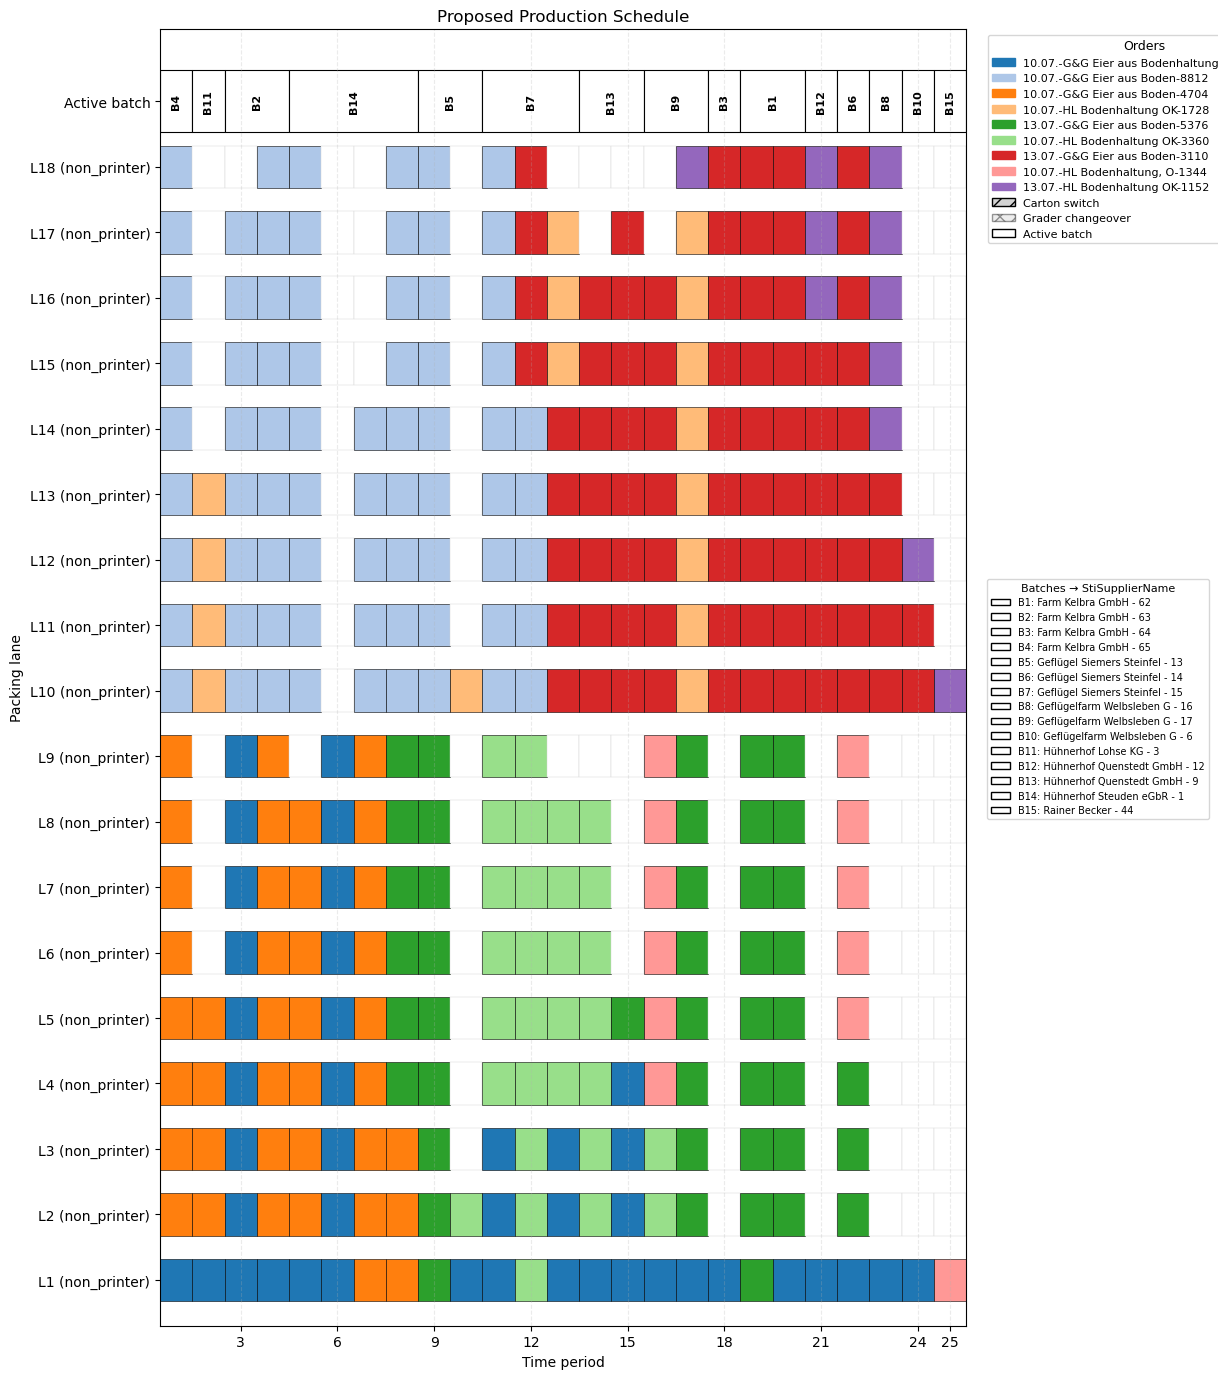

In [9]:
# ============================================================
# Visualize production schedule - Aggregated lane-group model
# Cleaner version: limited x-axis labels, no block text,
# active batch displayed once in a separate row
#
# Changes included:
# 1. Active-batch row still shows B1, B2, ...
# 2. Extra legend shows B1, B2, ... -> original StiSupplierName
# 3. Order legend shows erpId instead of O1, O2, ...
# ============================================================

if model.SolCount > 0:

    import math
    import copy
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib import colormaps


    # ------------------------------------------------------------
    # Helper functions
    # ------------------------------------------------------------

    def lane_number(l):
        """Extract numeric part of lane name such as L12 -> 12."""
        return int("".join(ch for ch in str(l) if ch.isdigit()))


    def order_number(o):
        """Extract numeric part of order name such as O12 -> 12."""
        digits = "".join(ch for ch in str(o) if ch.isdigit())
        return int(digits) if digits else 999999


    def batch_number(b):
        """Extract numeric part of batch name such as B12 -> 12."""
        digits = "".join(ch for ch in str(b) if ch.isdigit())
        return int(digits) if digits else 999999


    def get_order_legend_label(o):
        """
        Return order description for order legend.
        Falls back to O1/O2/... if description is unavailable.
        """
    
        def valid_value(value):
            return value is not None and str(value).strip() != ""
    
        def get_description_from_metadata(order, metadata):
            if order in metadata:
                description = metadata[order].get("description", None)
    
                if valid_value(description):
                    return str(description)
    
            return None
    
        # ------------------------------------------------------------
        # Main case
        # ------------------------------------------------------------
    
        if "order_metadata" in globals():
            description = get_description_from_metadata(o, order_metadata)
    
            if description is not None:
                return description
    
        # ------------------------------------------------------------
        # Optional backup metadata, if you created one before combining orders
        # ------------------------------------------------------------
    
        for backup_name in [
            "order_metadata_before_order_combination",
            "old_order_metadata",
            "original_order_metadata",
        ]:
            if backup_name in globals():
                backup_metadata = globals()[backup_name]
    
                description = get_description_from_metadata(
                    o,
                    backup_metadata
                )
    
                if description is not None:
                    return description
    
        # ------------------------------------------------------------
        # DataFrame fallback
        # ------------------------------------------------------------
    
        if "orders_on_day" in globals():
            if (
                "modelOrder" in orders_on_day.columns
                and "description" in orders_on_day.columns
            ):
                matches = orders_on_day.loc[
                    orders_on_day["modelOrder"] == o,
                    "description"
                ]
    
                if len(matches) > 0:
                    description = matches.iloc[0]
    
                    if valid_value(description):
                        return str(description)
    
        # ------------------------------------------------------------
        # Combined-order fallback
        # Example: O1&O2&O4&O8
        # Returns unique descriptions joined together.
        # ------------------------------------------------------------
    
        if "&" in str(o):
            original_orders = str(o).split("&")
            descriptions = []
    
            for original_o in original_orders:
                label = get_order_legend_label(original_o)
    
                if label != original_o:
                    descriptions.append(label)
    
            descriptions = list(dict.fromkeys(descriptions))
    
            if len(descriptions) > 0:
                return " + ".join(descriptions)
    
        return str(o)


    def get_batch_supplier_label(b):
        """
        Return original raw supplier name for batch legend.
        Falls back to other metadata if RawSupplierName is unavailable.
        """

        if "batch_metadata" in globals() and b in batch_metadata:

            for key in [
                "RawSupplierName",
                "StiSupplierName",
                "StiSupplierNames",
                "RawSupplierNames",
                "SupplierName",
            ]:
                value = batch_metadata[b].get(key, None)

                if value is not None and str(value).strip() != "":
                    return str(value)

        return "Unknown supplier"


    def get_group_of_lane(l):
        """Return the lane group of lane l."""
        if pi[l] == 1:
            return "printer"
        return "non_printer"


    def get_lanes_in_group(g):
        """Return lanes belonging to group g, sorted by lane index."""
        if g == "printer":
            return sorted([l for l in L if pi[l] == 1], key=lane_number)

        if g == "non_printer":
            return sorted([l for l in L if pi[l] == 0], key=lane_number)

        return []


    def get_active_batch_in_period(t):
        """Return active batch in period t, or None."""
        active_batches = [
            b for b in B
            if value_or_zero(s[(b, t)]) > 0.5
        ]

        return active_batches[0] if active_batches else None


    def get_total_quantity_for_group_order(g, t, o):
        """Return total quantity produced for order o in group g and period t."""
        return sum(
            value_or_zero(x[key])
            for key in x_by_ogt[(o, g, t)]
        )


    def build_lane_level_schedule():
        """
        Convert aggregated y[o,g,t] and x[b,k,o,g,t] values to a lane-level schedule.
    
        Important:
        - If carton_state exists, the visualization respects the model's hidden
          lane setup state.
        - Idle lanes keep their carton setup.
        - Carton switch markers are based on setup changes, not on arbitrary
          reconstructed order changes.
        """
    
        local_y_index_set = set(Y_INDEX)
    
        carton_types = list(dict.fromkeys(a_order[o] for o in O))
    
        orders_by_carton = {
            a: [o for o in O if a_order[o] == a]
            for a in carton_types
        }
    
        schedule = {
            (l, t): {
                "order": None,
                "qty": 0,
                "group": get_group_of_lane(l),
                "setup_carton": None,
                "carton_switch_boundary": False,
            }
            for l in L
            for t in T
        }
    
        def y_carton_value(a, g, t):
            return sum(
                value_or_zero(y[(o, g, t)])
                for o in orders_by_carton[a]
                if (o, g, t) in local_y_index_set
            )
    
        def get_setup_counts(g, t):
            """
            Number of lanes in group g configured for each carton type in period t.
            Prefer optimized carton_state. Fallback: use active carton usage.
            """
    
            if "carton_state" in globals():
                counts = {
                    a: int(round(value_or_zero(carton_state[(a, g, t)])))
                    for a in carton_types
                }
            else:
                counts = {
                    a: int(round(y_carton_value(a, g, t)))
                    for a in carton_types
                }
    
                # Put remaining idle lanes on the first carton type as fallback.
                used = sum(counts.values())
                if used < N_group[g] and len(carton_types) > 0:
                    counts[carton_types[0]] += N_group[g] - used
    
            return counts
    
        # --------------------------------------------------------
        # Step 1: assign carton setup state to physical lanes
        # --------------------------------------------------------
    
        for g in G:
            lanes_g = get_lanes_in_group(g)
            previous_setup = {l: None for l in lanes_g}
    
            for t in sorted(T):
                target_counts = get_setup_counts(g, t)
                remaining_need = target_counts.copy()
    
                new_setup = {}
                unused_lanes = lanes_g.copy()
    
                # First keep as many previous carton setups as possible
                for a in carton_types:
                    lanes_already_on_a = [
                        l for l in lanes_g
                        if previous_setup.get(l) == a
                    ]
    
                    keep_count = min(
                        len(lanes_already_on_a),
                        remaining_need.get(a, 0)
                    )
    
                    for l in lanes_already_on_a[:keep_count]:
                        new_setup[l] = a
                        unused_lanes.remove(l)
                        remaining_need[a] -= 1
    
                # Then assign remaining setup requirements
                for a in carton_types:
                    while remaining_need.get(a, 0) > 0 and len(unused_lanes) > 0:
                        l = unused_lanes.pop(0)
                        new_setup[l] = a
                        remaining_need[a] -= 1
    
                # Safety fallback for any leftover lanes
                for l in unused_lanes:
                    new_setup[l] = carton_types[0] if len(carton_types) > 0 else None
    
                # Store setup state and setup-switch markers
                for l in lanes_g:
                    schedule[(l, t)]["setup_carton"] = new_setup[l]
    
                    if (
                        previous_setup.get(l) is not None
                        and new_setup[l] != previous_setup.get(l)
                    ):
                        schedule[(l, t)]["carton_switch_boundary"] = True
    
                previous_setup = new_setup
    
        # --------------------------------------------------------
        # Step 2: assign actual production to lanes with matching setup
        # --------------------------------------------------------
    
        for t in sorted(T):
            for g in G:
                lanes_g = get_lanes_in_group(g)
    
                free_lanes_by_carton = {
                    a: [
                        l for l in lanes_g
                        if schedule[(l, t)]["setup_carton"] == a
                    ]
                    for a in carton_types
                }
    
                active_orders = []
    
                for o in O:
                    if (o, g, t) not in local_y_index_set:
                        continue
    
                    produced_qty = get_total_quantity_for_group_order(g, t, o)
    
                    if produced_qty <= 1e-6:
                        continue
    
                    y_value = value_or_zero(y[(o, g, t)])
    
                    lanes_needed_from_qty = math.ceil(produced_qty / C_lane)
                    lanes_allowed_by_y = max(1, round(y_value))
    
                    displayed_lanes = min(
                        lanes_needed_from_qty,
                        lanes_allowed_by_y
                    )
    
                    active_orders.append({
                        "order": o,
                        "carton": a_order[o],
                        "displayed_lanes": displayed_lanes,
                        "produced_qty": produced_qty,
                    })
    
                active_orders.sort(key=lambda row: order_number(row["order"]))
    
                for row in active_orders:
                    o = row["order"]
                    a = row["carton"]
                    displayed_lanes = row["displayed_lanes"]
                    produced_qty = row["produced_qty"]
    
                    qty_per_lane = (
                        produced_qty / displayed_lanes
                        if displayed_lanes > 0
                        else 0
                    )
    
                    for _ in range(displayed_lanes):
                        if len(free_lanes_by_carton.get(a, [])) == 0:
                            print(
                                f"Warning: not enough setup lanes for carton {a} "
                                f"in group {g}, period {t}."
                            )
                            break
    
                        l = free_lanes_by_carton[a].pop(0)
    
                        schedule[(l, t)]["order"] = o
                        schedule[(l, t)]["qty"] = qty_per_lane
    
        return schedule


    def get_batch_runs():
        """
        Return contiguous active-batch runs for the separate batch row.

        Each item is:
            (batch, start_period, end_period)

        where end_period is inclusive.
        """

        runs = []

        current_batch = None
        run_start = None

        for t in T:
            b = get_active_batch_in_period(t)

            if b != current_batch:
                if current_batch is not None:
                    runs.append((current_batch, run_start, t - 1))

                current_batch = b
                run_start = t if b is not None else None

        if current_batch is not None:
            runs.append((current_batch, run_start, max(T)))

        return runs


    def get_limited_xticks(T_values, max_ticks=12):
        """
        Return at most max_ticks x-axis tick labels.
        For 96 periods and max_ticks=12, this returns roughly 8,16,24,...,96.
        """

        t_min_local = min(T_values)
        t_max_local = max(T_values)
        n_periods = len(T_values)

        if n_periods <= max_ticks:
            return T_values

        step = math.ceil(n_periods / max_ticks)

        ticks = [
            t for t in T_values
            if t % step == 0
        ]

        if t_max_local not in ticks:
            ticks.append(t_max_local)

        return ticks[:max_ticks] if len(ticks) > max_ticks else ticks


    lane_schedule = build_lane_level_schedule()


    # ============================================================
    # Visualization preprocessing: expand combined orders back
    # ============================================================
    # Model may contain combined orders such as O1&O3&O5.
    # For visualization, we assign production cells back to the original orders.
    #
    # Assignment order:
    # 1. low lane number first
    # 2. then low time period
    #
    # Example:
    # If model order is O1&O3&O5, the visualization first assigns cells to O1,
    # then O3, then O5.
    # ============================================================

    def expand_combined_orders_for_visualization(lane_schedule):
        """
        Returns a copy of lane_schedule where combined model orders are expanded
        into original visual order labels.

        The original model order is kept in cell["modelOrder"].
        The visual order is written to cell["order"].
        """

        expanded_schedule = copy.deepcopy(lane_schedule)

        # If no order aggregation was done, do nothing
        if "new_to_old_orders" not in globals():
            print("No combined-order mapping found. Visualization orders unchanged.")
            return expanded_schedule

        # If original demand backup is missing, fall back to equal splitting
        has_original_demands = "D_before_order_combination" in globals()

        if not has_original_demands:
            print(
                "Warning: D_before_order_combination not found. "
                "Combined orders will be split approximately equally for visualization."
            )

        # --------------------------------------------------------
        # Make original orders usable in visualization dictionaries
        # --------------------------------------------------------
        # This prevents KeyErrors later if plotting code looks up a_order[o],
        # q_order[o], rho[o], etc. using the visual order name.
        # --------------------------------------------------------

        for model_o, original_orders in new_to_old_orders.items():
            for original_o in original_orders:

                if "a_order" in globals() and original_o not in a_order:
                    a_order[original_o] = a_order[model_o]

                if "q_order" in globals() and original_o not in q_order:
                    q_order[original_o] = q_order[model_o]

                if "rho" in globals() and original_o not in rho:
                    rho[original_o] = rho[model_o]

        # --------------------------------------------------------
        # Expand each combined order separately
        # --------------------------------------------------------

        for model_o, original_orders in new_to_old_orders.items():

            # Nothing to expand for normal single orders
            if len(original_orders) == 1:
                continue

            # All occupied visualization cells for this combined model order
            cells_for_model_order = []

            for (l, t), cell in expanded_schedule.items():
                if cell["order"] == model_o:
                    cells_for_model_order.append((l, t, cell))

            if len(cells_for_model_order) == 0:
                continue

            # Sort low lane first, then low time period
            cells_for_model_order = sorted(
                cells_for_model_order,
                key=lambda item: (item[1], item[0])
            )

            total_visual_qty = sum(
                cell.get("qty", 0)
                for _, _, cell in cells_for_model_order
            )

            # Target quantity per original order
            if has_original_demands:
                target_qty_by_original_order = {
                    original_o: D_before_order_combination[original_o]
                    for original_o in original_orders
                }
            else:
                equal_target = total_visual_qty / len(original_orders)

                target_qty_by_original_order = {
                    original_o: equal_target
                    for original_o in original_orders
                }

            # ----------------------------------------------------
            # Assign cells: first all required cells to first order,
            # then to second order, etc.
            # ----------------------------------------------------

            current_original_index = 0
            produced_for_current_original = 0

            for l, t, cell in cells_for_model_order:

                current_original_o = original_orders[current_original_index]
                current_target = target_qty_by_original_order[current_original_o]

                # Keep the aggregate/model order for traceability
                cell["modelOrder"] = model_o

                # Replace visible order with original order
                cell["order"] = current_original_o

                produced_for_current_original += cell.get("qty", 0)

                # Move to next original order once the current one is sufficiently filled
                if (
                    produced_for_current_original >= current_target
                    and current_original_index < len(original_orders) - 1
                ):
                    current_original_index += 1
                    produced_for_current_original = 0

            print(
                f"Expanded {model_o} into {original_orders} "
                f"for visualization | visual qty = {total_visual_qty:,.0f}"
            )

        return expanded_schedule


    # Apply expansion
    lane_schedule = expand_combined_orders_for_visualization(lane_schedule)


    # ============================================================
    # Cut visualization horizon at actual makespan
    # ============================================================
    # This removes idle time after the final production period.
    # ============================================================

    active_periods_in_visual_schedule = [
        t
        for (l, t), cell in lane_schedule.items()
        if cell["order"] is not None
    ]

    if len(active_periods_in_visual_schedule) == 0:
        raise ValueError("No active production periods found in lane_schedule.")

    visual_makespan = max(active_periods_in_visual_schedule)

    T_vis = [
        t for t in T
        if t <= visual_makespan
    ]

    print("\nVisualization horizon shortened.")
    print(f"Original horizon: {min(T)} to {max(T)}")
    print(f"Visual horizon:   {min(T_vis)} to {max(T_vis)}")
    print(f"Visual makespan:  {visual_makespan}")


    # ============================================================
    # Create colors for the actual orders shown in the visualization
    # ============================================================
    # Important:
    # After expanding combined orders, lane_schedule may contain original orders
    # such as O1, O2, O4, even if the model order was O1&2&4.
    # Therefore colors must be based on lane_schedule, not only on O.
    # ============================================================

    cmap = colormaps["tab20"]

    visual_orders = list(
        dict.fromkeys(
            cell["order"]
            for (l, t), cell in sorted(
                lane_schedule.items(),
                key=lambda item: (item[0][1], item[0][0])  # time first, then lane
            )
            if cell["order"] is not None
        )
    )

    order_colors = {
        o: cmap(i % cmap.N)
        for i, o in enumerate(visual_orders)
    }


    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    L_sorted = sorted(L, key=lane_number)

    # Wider figure to leave room for two legends on the right
    fig, ax = plt.subplots(figsize=(18, 0.55 * len(L_sorted) + 4))

    bar_height = 0.65

    # Leave one extra row at the top for active batch
    lane_positions = {
        l: i
        for i, l in enumerate(L_sorted)
    }

    batch_y_pos = len(L_sorted)
    all_y_positions = list(lane_positions.values()) + [batch_y_pos]


    # ------------------------------------------------------------
    # Draw production blocks
    # ------------------------------------------------------------

    for l in L_sorted:
        y_pos = lane_positions[l]

        for t in T_vis:
            cell = lane_schedule[(l, t)]
            o = cell["order"]

            # Production block
            if o is not None:
                ax.barh(
                    y=y_pos,
                    width=1,
                    left=t - 0.5,
                    height=bar_height,
                    color=order_colors[o],
                    edgecolor="black",
                    linewidth=0.4
                )

            # Idle block
            else:
                ax.barh(
                    y=y_pos,
                    width=1,
                    left=t - 0.5,
                    height=bar_height,
                    color="white",
                    edgecolor="lightgrey",
                    linewidth=0.3
                )

            # Inferred carton-switch marker.
            # This is not production downtime in the aggregate model.
            if cell["carton_switch_boundary"]:
                ax.barh(
                    y=y_pos,
                    width=0.12,
                    left=t - 0.56,
                    height=bar_height,
                    color="lightgrey",
                    edgecolor="black",
                    hatch="//",
                    linewidth=0.6
                )


    # ------------------------------------------------------------
    # Draw active-batch row
    # ------------------------------------------------------------

    batch_runs = get_batch_runs()

    batch_bar_height = 0.95
    batch_fontsize = 8

    for b, start_t, end_t in batch_runs:

        # Do not draw batch blocks beyond the visualization horizon
        if start_t > max(T_vis):
            continue

        clipped_start_t = max(start_t, min(T_vis))
        clipped_end_t = min(end_t, max(T_vis))

        width = clipped_end_t - clipped_start_t + 1
        left = clipped_start_t - 0.5
        center_x = left + width / 2

        batch_patch = ax.barh(
            y=batch_y_pos,
            width=width,
            left=left,
            height=batch_bar_height,
            color="white",
            edgecolor="black",
            linewidth=0.8
        )[0]

        batch_text = ax.text(
            x=center_x,
            y=batch_y_pos,
            s=b,
            ha="center",
            va="center",
            fontsize=batch_fontsize,
            fontweight="bold",
            rotation=90,
            rotation_mode="anchor",
            clip_on=True
        )

        batch_text.set_clip_path(batch_patch)


    # ------------------------------------------------------------
    # Add grader-level changeover markers
    # ------------------------------------------------------------

    for t in T_vis:
        if value_or_zero(z_grader[t]) > 0.5:
            ax.axvspan(
                t - 0.5,
                t + 0.5,
                facecolor="lightgrey",
                edgecolor="black",
                alpha=0.25,
                hatch="xx",
                linewidth=0.0
            )


    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------

    ax.set_yticks(all_y_positions)
    ax.set_yticklabels(
        [
            f"{l} ({get_group_of_lane(l)})"
            for l in L_sorted
        ]
        + ["Active batch"]
    )

    xticks = get_limited_xticks(T_vis, max_ticks=12)
    ax.set_xticks(xticks)

    ax.set_xlabel("Time period")
    ax.set_ylabel("Packing lane")
    ax.set_title("Proposed Production Schedule")

    ax.set_xlim(min(T_vis) - 0.5, max(T_vis) + 0.5)
    ax.set_ylim(-0.7, batch_y_pos + 1.1)

    ax.grid(axis="x", linestyle="--", alpha=0.25)


    # ------------------------------------------------------------
    # Legend 1: Orders
    # ------------------------------------------------------------

    order_patches = [
        mpatches.Patch(
            color=color,
            label=get_order_legend_label(o)
        )
        for o, color in order_colors.items()
    ]

    carton_switch_patch = mpatches.Patch(
        facecolor="lightgrey",
        edgecolor="black",
        hatch="//",
        label="Carton switch"
    )

    grader_changeover_patch = mpatches.Patch(
        facecolor="lightgrey",
        edgecolor="black",
        hatch="xx",
        alpha=0.4,
        label="Grader changeover"
    )

    active_batch_patch = mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Active batch"
    )

    main_legend_handles = order_patches + [
        carton_switch_patch,
        grader_changeover_patch,
        active_batch_patch
    ]

    main_legend = ax.legend(
        handles=main_legend_handles,
        title="Orders",
        bbox_to_anchor=(1.02, 1.00),
        loc="upper left",
        fontsize=8,
        title_fontsize=9
    )

    ax.add_artist(main_legend)


    # ------------------------------------------------------------
    # Legend 2: Batches to original StiSupplierName
    # ------------------------------------------------------------

    batch_legend_handles = [
        mpatches.Patch(
            facecolor="white",
            edgecolor="black",
            label=f"{b}: {get_batch_supplier_label(b)}"
        )
        for b in sorted(B, key=batch_number)
    ]

    ax.legend(
        handles=batch_legend_handles,
        title="Batches → StiSupplierName",
        bbox_to_anchor=(1.02, 0.58),
        loc="upper left",
        fontsize=7,
        title_fontsize=8
    )


    # Leave room on the right for both legends
    plt.tight_layout(rect=[0, 0, 0.74, 1])
    plt.show()

else:
    print("No feasible solution available, so schedule visualization cannot be created.")

In [10]:
# ============================================================
# Concise KPI report
# Uses the setup-state-aware visualization logic
# ============================================================

if model.SolCount > 0:

    # ------------------------------------------------------------
    # Always rebuild lane schedule
    # Important: prevents using an old/stale visualization schedule
    # ------------------------------------------------------------

    lane_schedule = build_lane_level_schedule()

    # ------------------------------------------------------------
    # Makespan
    # ------------------------------------------------------------

    makespan_kpi = value_or_zero(makespan)

    # ------------------------------------------------------------
    # Demand satisfied
    # ------------------------------------------------------------

    total_demand = sum(D[o] for o in O)

    total_fulfilled = sum(
        value_or_zero(x[key])
        for key in X_INDEX
    )

    demand_satisfied_pct = (
        100 * total_fulfilled / total_demand
        if total_demand > 0
        else 0
    )

    # ------------------------------------------------------------
    # Scrap
    # ------------------------------------------------------------

    total_available_supply = sum(
        S[(b, k)]
        for b in B
        for k in K
    )

    total_scrap = sum(
        value_or_zero(scrap[(b, k)])
        for b in B
        for k in K
    )

    scrap_pct = (
        100 * total_scrap / total_available_supply
        if total_available_supply > 0
        else 0
    )

    # ------------------------------------------------------------
    # Lane changeovers
    # A lane changeover means a lane changes from one carton type to another.
    # ------------------------------------------------------------
    
    lane_changeovers = sum(
        value_or_zero(lane_setup_chg[(g, t)])
        for g in G
        for t in T_not_first
    )
    
    # Include initial setup changes only if you explicitly added them to the objective
    if "initial_lane_setup_chg" in globals():
        lane_changeovers += sum(
            value_or_zero(initial_lane_setup_chg[g])
            for g in G
        )

    # ------------------------------------------------------------
    # Full grader changeovers
    # ------------------------------------------------------------

    full_grader_changeovers = sum(
        value_or_zero(z_grader[t])
        for t in T
    )

    # ------------------------------------------------------------
    # Print KPI summary
    # ------------------------------------------------------------

    print("\n" + "=" * 50)
    print("KPI SUMMARY")
    print("=" * 50)
    print(f"Runtime:                         {runtime / 60:.2f} minutes")
    print(f"Makespan:                        {makespan_kpi:,.0f} periods")
    print(f"Demand satisfied:                {demand_satisfied_pct:,.2f}%")
    print(f"Scrap:                           {scrap_pct:,.2f}%")
    print(f"Lane Changeovers:                {lane_changeovers:,.0f}")
    print(f"Full grader changeovers:         {full_grader_changeovers:,.0f}")
    print(f"Norm. Downgrading:               {downgrading_cost / DOWNGRADE_COST_PER_SIZE_STEP:,.1f}")

else:
    print("No feasible solution available, so KPIs cannot be reported.")


KPI SUMMARY
Runtime:                         18.96 minutes
Makespan:                        25 periods
Demand satisfied:                99.77%
Scrap:                           2.00%
Lane Changeovers:                0
Full grader changeovers:         0
Norm. Downgrading:               355,913.0


In [11]:
# ============================================================
# Save original Scenario 13 solution before repair
# ============================================================

base_x = {
    key: x[key].X
    for key in X_INDEX
}

base_y = {
    key: y[key].X
    for key in Y_INDEX
}

base_s = {
    (b, t): s[b, t].X
    for b in B
    for t in T
}

base_e = {
    (b, t): e[b, t].X
    for b in B
    for t in T
}

base_r = {
    (q, t): r[q, t].X
    for q in Q
    for t in T
}

base_z_grader = {
    t: z_grader[t].X
    for t in T
}

base_carton_state = {
    (a, g, t): carton_state[a, g, t].X
    for a in A
    for g in G
    for t in T
}

base_makespan = makespan.X

In [12]:
ROBUSTNESS_CASE_NUMBER = 1
ROBUSTNESS_CASE_NAME = "5% proportional supply reduction"

PROPORTIONAL_SUPPLY_REDUCTION = 0.05
REDUCED_L_SUPPLY = 0.00

SHIFT_FROM = None
SHIFT_TO = None
SHIFT_PERCENTAGE = 0.00

METHOD = "Repair"

In [13]:
# ============================================================
# Apply robustness case to supply S
# Place this AFTER the cell that generates S
# and BEFORE the model-building cells
# ============================================================

S_base = S.copy()   # keep original supply for reference if needed later


def apply_robustness_to_S(
    S_input,
    B,
    K,
    proportional_supply_reduction=0.0,
    reduced_l_supply=0.0,
    shift_from=None,
    shift_to=None,
    shift_percentage=0.0,
    round_to_int=True,
):
    """
    Returns a modified copy of S_input.

    Modification order:
    1. Proportional reduction on all supply
    2. Additional reduction on L supply only
    3. Shift a percentage of supply from one size class to another within each batch
    """

    S_new = S_input.copy()

    # -------------------------------
    # Basic validation
    # -------------------------------
    for name, value in [
        ("proportional_supply_reduction", proportional_supply_reduction),
        ("reduced_l_supply", reduced_l_supply),
        ("shift_percentage", shift_percentage),
    ]:
        if value < 0 or value > 1:
            raise ValueError(f"{name} must be between 0 and 1, got {value}.")

    if shift_from is not None and shift_from not in K:
        raise ValueError(f"SHIFT_FROM '{shift_from}' is not in K = {K}")

    if shift_to is not None and shift_to not in K:
        raise ValueError(f"SHIFT_TO '{shift_to}' is not in K = {K}")

    if shift_from is not None and shift_to is not None and shift_from == shift_to:
        raise ValueError("SHIFT_FROM and SHIFT_TO cannot be the same.")

    # -------------------------------
    # 1. Proportional reduction
    # -------------------------------
    if proportional_supply_reduction > 0:
        factor = 1.0 - proportional_supply_reduction
        for b in B:
            for k in K:
                S_new[(b, k)] = S_new.get((b, k), 0) * factor

    # -------------------------------
    # 2. Additional reduction of L supply
    # -------------------------------
    if reduced_l_supply > 0:
        if "L" not in K:
            raise ValueError("REDUCED_L_SUPPLY was specified, but 'L' is not in K.")
        factor = 1.0 - reduced_l_supply
        for b in B:
            S_new[(b, "L")] = S_new.get((b, "L"), 0) * factor

    # -------------------------------
    # 3. Shift within each batch
    # -------------------------------
    shift_active = (
        shift_from is not None
        and shift_to is not None
        and shift_percentage > 0
    )

    if shift_active:
        for b in B:
            available_from = S_new.get((b, shift_from), 0)

            if round_to_int:
                amount_shifted = int(round(available_from * shift_percentage))
            else:
                amount_shifted = available_from * shift_percentage

            # safety
            amount_shifted = min(amount_shifted, S_new.get((b, shift_from), 0))
            amount_shifted = max(amount_shifted, 0)

            S_new[(b, shift_from)] = S_new.get((b, shift_from), 0) - amount_shifted
            S_new[(b, shift_to)]   = S_new.get((b, shift_to), 0) + amount_shifted

    # -------------------------------
    # Optional rounding / cleanup
    # -------------------------------
    if round_to_int:
        for key in list(S_new.keys()):
            S_new[key] = int(round(S_new[key]))
            if S_new[key] < 0:
                S_new[key] = 0

    return S_new


# Apply the selected robustness case
S = apply_robustness_to_S(
    S_input=S_base,
    B=B,
    K=K,
    proportional_supply_reduction=PROPORTIONAL_SUPPLY_REDUCTION,
    reduced_l_supply=REDUCED_L_SUPPLY,
    shift_from=SHIFT_FROM,
    shift_to=SHIFT_TO,
    shift_percentage=SHIFT_PERCENTAGE,
    round_to_int=True,
)

print(f"Applied robustness case {ROBUSTNESS_CASE_NUMBER}: {ROBUSTNESS_CASE_NAME}")
print(f"METHOD = {METHOD}")
print(f"PROPORTIONAL_SUPPLY_REDUCTION = {PROPORTIONAL_SUPPLY_REDUCTION}")
print(f"REDUCED_L_SUPPLY = {REDUCED_L_SUPPLY}")
print(f"SHIFT_FROM = {SHIFT_FROM}")
print(f"SHIFT_TO = {SHIFT_TO}")
print(f"SHIFT_PERCENTAGE = {SHIFT_PERCENTAGE}")

total_supply_before = sum(S_base.values())
total_supply_after = sum(S.values())

print(f"Total supply before: {total_supply_before}")
print(f"Total supply after : {total_supply_after}")

print("\nSupply by size before -> after:")
for k in K:
    before_k = sum(S_base.get((b, k), 0) for b in B)
    after_k  = sum(S.get((b, k), 0) for b in B)
    print(f"{k:>3}: {before_k:>8} -> {after_k:>8}")

Applied robustness case 1: 5% proportional supply reduction
METHOD = Repair
PROPORTIONAL_SUPPLY_REDUCTION = 0.05
REDUCED_L_SUPPLY = 0.0
SHIFT_FROM = None
SHIFT_TO = None
SHIFT_PERCENTAGE = 0.0
Total supply before: 406250
Total supply after : 385941

Supply by size before -> after:
  S:    16026 ->    15227
  M:   275469 ->   261696
  L:   108621 ->   103188
 XL:     6056 ->     5755
XXL:       78 ->       75


In [14]:
# ============================================================
# Repair original Scenario 13 schedule under modified supply S
# ============================================================

def repair_original_solution(
    repair_time_limit=600,
    repair_output_flag=0,
    tolerance=1e-6,
):
    """
    Repair the original solved Scenario 13 schedule under the
    currently modified supply dictionary S.

    Fixed from the original solution:
    - active batch in each period: s[b,t]
    - available order/lane-group/time slots: y[o,g,t]
    - lane capacity allocated to each order slot
    - grader changeover periods: z_grader[t]
    - lane setup and grader configuration structure

    Reoptimized:
    - egg allocations x[b,k,o,g,t]
    - unmet demand u[o]
    - scrap[b,k]

    The repair model is a continuous LP, with no binary or integer
    decision variables.

    Runtime reported below includes ONLY repair_model.optimize().
    """

    # ============================================================
    # 1. Store the original solved schedule
    # ============================================================

    if model.SolCount <= 0:
        raise RuntimeError(
            "The original Scenario 13 model has no feasible solution."
        )

    # Original x allocations
    base_x = {
        key: value_or_zero(x[key])
        for key in X_INDEX
    }

    # Original integer lane assignments
    base_y = {
        key: max(0, int(round(value_or_zero(y[key]))))
        for key in Y_INDEX
    }

    # Original active batches
    base_s = {
        (b, t): value_or_zero(s[(b, t)])
        for b in B
        for t in T
    }

    # Original grader changeover periods
    base_z_grader = {
        t: value_or_zero(z_grader[t])
        for t in T
    }

    # Original lane-changeover KPI
    base_lane_changeovers = sum(
        value_or_zero(lane_setup_chg[(g, t)])
        for g in G
        for t in T_not_first
    )

    if "initial_lane_setup_chg" in globals():
        base_lane_changeovers += sum(
            value_or_zero(initial_lane_setup_chg[g])
            for g in G
        )

    # Original grader-changeover KPI
    base_full_grader_changeovers = sum(
        base_z_grader[t]
        for t in T
    )

    # ============================================================
    # 2. Identify the fixed original schedule structure
    # ============================================================

    # Active batch in every period
    active_batch_by_time = {}

    for t in T:
        active_batches = [
            b
            for b in B
            if base_s[(b, t)] > 0.5
        ]

        if len(active_batches) > 1:
            raise RuntimeError(
                f"More than one active batch found in period {t}: "
                f"{active_batches}"
            )

        active_batch_by_time[t] = (
            active_batches[0]
            if active_batches
            else None
        )

    # Only retain order/group/time slots used in the original solution
    REPAIR_ACTIVE_SLOTS = [
        (o, g, t)
        for (o, g, t) in Y_INDEX
        if base_y[(o, g, t)] >= 1
    ]

    # Check that every used order slot has an active batch
    for o, g, t in REPAIR_ACTIVE_SLOTS:
        if active_batch_by_time[t] is None:
            raise RuntimeError(
                f"Original solution has y[{o},{g},{t}] > 0, "
                f"but no active batch in period {t}."
            )

    # ============================================================
    # 3. Construct repair allocation indices
    # ============================================================
    #
    # Important:
    # This is not limited to the original X_INDEX.
    #
    # A quality class introduced through a shift may originally have
    # had zero supply and therefore no original x variable. It must
    # still be available to the repair model.
    # ============================================================

    REPAIR_X_INDEX = []

    for o, g, t in REPAIR_ACTIVE_SLOTS:

        b = active_batch_by_time[t]

        for k in K:

            if S[(b, k)] <= tolerance:
                continue

            if delta[(b, k, o)] != 1:
                continue

            if eta[b] == 1 and t not in T_end:
                continue

            REPAIR_X_INDEX.append((b, k, o, g, t))

    REPAIR_X_INDEX_SET = set(REPAIR_X_INDEX)

    # ============================================================
    # 4. Precompute index groups
    # ============================================================

    repair_x_by_order = {
        o: []
        for o in O
    }

    repair_x_by_batch_class = {
        (b, k): []
        for b in B
        for k in K
    }

    repair_x_by_slot = {
        slot: []
        for slot in REPAIR_ACTIVE_SLOTS
    }

    repair_x_by_time = {
        t: []
        for t in T
    }

    for key in REPAIR_X_INDEX:

        b, k, o, g, t = key

        repair_x_by_order[o].append(key)
        repair_x_by_batch_class[(b, k)].append(key)
        repair_x_by_slot[(o, g, t)].append(key)
        repair_x_by_time[t].append(key)

    # Original production quantity in every retained order slot
    base_slot_quantity = {
        slot: 0.0
        for slot in REPAIR_ACTIVE_SLOTS
    }

    for key, quantity in base_x.items():

        b, k, o, g, t = key
        slot = (o, g, t)

        if slot in base_slot_quantity:
            base_slot_quantity[slot] += quantity

    # ============================================================
    # 5. Create repair LP
    # ============================================================

    repair_model = gp.Model("Sanovo_Schedule_Repair")
    repair_model.ModelSense = GRB.MINIMIZE

    # ------------------------------------------------------------
    # Repair allocation variables
    # ------------------------------------------------------------

    repair_x = repair_model.addVars(
        REPAIR_X_INDEX,
        lb=0.0,
        vtype=GRB.CONTINUOUS,
        name="repair_x"
    )

    # Tight individual upper bounds
    for b, k, o, g, t in REPAIR_X_INDEX:

        slot_capacity = (
            C_lane * base_y[(o, g, t)]
        )

        repair_x[(b, k, o, g, t)].UB = min(
            float(S[(b, k)]),
            float(slot_capacity)
        )

    # ------------------------------------------------------------
    # Unmet demand
    # ------------------------------------------------------------

    repair_u = repair_model.addVars(
        O,
        lb=0.0,
        vtype=GRB.CONTINUOUS,
        name="repair_u"
    )

    for o in O:
        repair_u[o].UB = D[o]

    # ------------------------------------------------------------
    # Scrap
    # ------------------------------------------------------------

    REPAIR_BK = [
        (b, k)
        for b in B
        for k in K
    ]

    repair_scrap = repair_model.addVars(
        REPAIR_BK,
        lb=0.0,
        vtype=GRB.CONTINUOUS,
        name="repair_scrap"
    )

    for b, k in REPAIR_BK:
        repair_scrap[(b, k)].UB = S[(b, k)]

    # ------------------------------------------------------------
    # Emergency minimum-demand shortfall
    # ------------------------------------------------------------
    #
    # This makes the repair model always solvable.
    # It is minimized before all other objectives.
    #
    # It will remain zero whenever the original hard minimum-demand
    # requirements can still be satisfied.
    # ------------------------------------------------------------

    repair_minimum_shortfall = repair_model.addVars(
        O,
        lb=0.0,
        vtype=GRB.CONTINUOUS,
        name="repair_minimum_shortfall"
    )

    for o in O:
        repair_minimum_shortfall[o].UB = D_min[o]

    # ------------------------------------------------------------
    # Deviation from original slot quantities
    # ------------------------------------------------------------
    #
    # This keeps the repaired schedule close to the original
    # order/group/time production pattern without forcing the
    # original quality-class allocation.
    # ------------------------------------------------------------

    repair_slot_deviation = repair_model.addVars(
        REPAIR_ACTIVE_SLOTS,
        lb=0.0,
        vtype=GRB.CONTINUOUS,
        name="repair_slot_deviation"
    )

    # ============================================================
    # 6. Repair constraints
    # ============================================================

    # ------------------------------------------------------------
    # Demand fulfillment
    # ------------------------------------------------------------

    for o in O:

        repair_model.addConstr(
            gp.quicksum(
                repair_x[key]
                for key in repair_x_by_order[o]
            )
            + repair_u[o]
            == D[o],
            name=f"Repair_Demand_{o}"
        )

    # ------------------------------------------------------------
    # Minimum demand fulfillment
    # ------------------------------------------------------------

    for o in O:

        repair_model.addConstr(
            gp.quicksum(
                repair_x[key]
                for key in repair_x_by_order[o]
            )
            + repair_minimum_shortfall[o]
            >= D_min[o],
            name=f"Repair_Minimum_Demand_{o}"
        )

    # ------------------------------------------------------------
    # Modified supply balance
    # ------------------------------------------------------------

    for b in B:
        for k in K:

            repair_model.addConstr(
                gp.quicksum(
                    repair_x[key]
                    for key in repair_x_by_batch_class[(b, k)]
                )
                + repair_scrap[(b, k)]
                == S[(b, k)],
                name=f"Repair_Supply_Balance_{b}_{k}"
            )

    # ------------------------------------------------------------
    # Fixed original lane capacity
    # ------------------------------------------------------------

    for o, g, t in REPAIR_ACTIVE_SLOTS:

        repair_model.addConstr(
            gp.quicksum(
                repair_x[key]
                for key in repair_x_by_slot[(o, g, t)]
            )
            <= C_lane * base_y[(o, g, t)],
            name=f"Repair_Lane_Capacity_{o}_{g}_{t}"
        )

    # ------------------------------------------------------------
    # Grader capacity
    # ------------------------------------------------------------

    for t in T:

        repair_model.addConstr(
            gp.quicksum(
                repair_x[key]
                for key in repair_x_by_time[t]
            )
            <= C_grader * (
                1 - round(base_z_grader[t])
            ),
            name=f"Repair_Grader_Capacity_{t}"
        )

    # ------------------------------------------------------------
    # Absolute slot deviation
    # ------------------------------------------------------------

    for o, g, t in REPAIR_ACTIVE_SLOTS:

        repaired_slot_quantity = gp.quicksum(
            repair_x[key]
            for key in repair_x_by_slot[(o, g, t)]
        )

        original_slot_quantity = (
            base_slot_quantity[(o, g, t)]
        )

        repair_model.addConstr(
            repair_slot_deviation[(o, g, t)]
            >= repaired_slot_quantity
            - original_slot_quantity,
            name=f"Repair_Positive_Deviation_{o}_{g}_{t}"
        )

        repair_model.addConstr(
            repair_slot_deviation[(o, g, t)]
            >= original_slot_quantity
            - repaired_slot_quantity,
            name=f"Repair_Negative_Deviation_{o}_{g}_{t}"
        )

    # ============================================================
    # 7. Hierarchical repair objectives
    # ============================================================
    #
    # Priority 3:
    #     Avoid violating minimum-demand requirements.
    #
    # Priority 2:
    #     Use the same economic allocation objective as the
    #     original model for the decisions that remain flexible.
    #
    # Priority 1:
    #     Keep production quantities close to the original
    #     order/group/time schedule.
    # ============================================================

    minimum_shortfall_expression = gp.quicksum(
        repair_minimum_shortfall[o]
        for o in O
    )

    repair_economic_expression = (
        gp.quicksum(
            c_down[(b, k, o)]
            * repair_x[(b, k, o, g, t)]
            for b, k, o, g, t in REPAIR_X_INDEX
        )
        +
        gp.quicksum(
            c_pen[o] * repair_u[o]
            for o in O
        )
        -
        gp.quicksum(
            c_scrap[k] * repair_scrap[(b, k)]
            for b in B
            for k in K
        )
    )

    slot_deviation_expression = gp.quicksum(
        repair_slot_deviation[slot]
        for slot in REPAIR_ACTIVE_SLOTS
    )

    repair_model.setObjectiveN(
        minimum_shortfall_expression,
        index=0,
        priority=3,
        weight=1.0,
        abstol=0.0,
        reltol=0.0,
        name="Minimize_Minimum_Demand_Shortfall"
    )

    repair_model.setObjectiveN(
        repair_economic_expression,
        index=1,
        priority=2,
        weight=1.0,
        abstol=0.0,
        reltol=0.0,
        name="Minimize_Repair_Economic_Cost"
    )

    repair_model.setObjectiveN(
        slot_deviation_expression,
        index=2,
        priority=1,
        weight=1.0,
        abstol=0.0,
        reltol=0.0,
        name="Minimize_Schedule_Deviation"
    )

    # ============================================================
    # 8. Solver settings
    # ============================================================

    repair_model.Params.TimeLimit = repair_time_limit
    repair_model.Params.OutputFlag = repair_output_flag

    # The repair problem contains continuous variables only.
    # Gurobi's automatic LP method is normally fastest.
    repair_model.Params.Method = -1

    repair_model.update()

    print("\n" + "=" * 80)
    print("START REPAIR")
    print("=" * 80)
    print(f"Repair allocation variables: {len(REPAIR_X_INDEX):,}")
    print(f"Fixed original order slots:  {len(REPAIR_ACTIVE_SLOTS):,}")

    # ============================================================
    # 9. Solve repair model
    # ============================================================
    #
    # IMPORTANT:
    # Only the optimize call is timed.
    # Model construction above and KPI extraction below are excluded.
    # ============================================================

    repair_solve_start = time.perf_counter()

    repair_model.optimize()

    repair_solve_end = time.perf_counter()

    repair_runtime = (
        repair_solve_end - repair_solve_start
    )

    # ============================================================
    # 10. Check repair status
    # ============================================================

    status_names = {
        GRB.OPTIMAL: "OPTIMAL",
        GRB.TIME_LIMIT: "TIME_LIMIT",
        GRB.INFEASIBLE: "INFEASIBLE",
        GRB.UNBOUNDED: "UNBOUNDED",
        GRB.INF_OR_UNBD: "INF_OR_UNBD",
    }

    repair_status = status_names.get(
        repair_model.Status,
        f"STATUS_{repair_model.Status}"
    )

    if repair_model.SolCount <= 0:

        print("\nNo feasible repair solution was found.")
        print(f"Repair status: {repair_status}")
        print(f"Repair runtime: {repair_runtime:.2f} seconds")

        return {
            "repair_model": repair_model,
            "status": repair_status,
            "runtime": repair_runtime,
            "solution_found": False,
        }

    # ============================================================
    # 11. Extract repaired solution
    # ============================================================

    repaired_x_values = {
        key: repair_x[key].X
        for key in REPAIR_X_INDEX
    }

    repaired_u_values = {
        o: repair_u[o].X
        for o in O
    }

    repaired_scrap_values = {
        (b, k): repair_scrap[(b, k)].X
        for b in B
        for k in K
    }

    repaired_minimum_shortfall_values = {
        o: repair_minimum_shortfall[o].X
        for o in O
    }

    # ============================================================
    # 12. Calculate repair KPIs
    # ============================================================

    # ------------------------------------------------------------
    # Makespan
    # Latest period containing positive repaired production
    # ------------------------------------------------------------

    production_by_time = {
        t: sum(
            repaired_x_values[key]
            for key in repair_x_by_time[t]
        )
        for t in T
    }

    active_repair_periods = [
        t
        for t in T
        if production_by_time[t] > tolerance
    ]

    repair_makespan_kpi = (
        max(active_repair_periods)
        if active_repair_periods
        else 0
    )

    # ------------------------------------------------------------
    # Demand satisfied
    # ------------------------------------------------------------

    repair_total_demand = sum(
        D[o]
        for o in O
    )

    repair_total_fulfilled = sum(
        repaired_x_values.values()
    )

    repair_demand_satisfied_pct = (
        100
        * repair_total_fulfilled
        / repair_total_demand
        if repair_total_demand > 0
        else 0
    )

    # ------------------------------------------------------------
    # Scrap
    # ------------------------------------------------------------

    repair_total_available_supply = sum(
        S[(b, k)]
        for b in B
        for k in K
    )

    repair_total_scrap = sum(
        repaired_scrap_values.values()
    )

    repair_scrap_pct = (
        100
        * repair_total_scrap
        / repair_total_available_supply
        if repair_total_available_supply > 0
        else 0
    )

    # ------------------------------------------------------------
    # Lane and grader changeovers
    # These remain fixed from the original schedule
    # ------------------------------------------------------------

    repair_lane_changeovers = (
        base_lane_changeovers
    )

    repair_full_grader_changeovers = (
        base_full_grader_changeovers
    )

    # ------------------------------------------------------------
    # Normalized downgrading
    # ------------------------------------------------------------

    repair_downgrading_cost = sum(
        c_down[(b, k, o)]
        * repaired_x_values[(b, k, o, g, t)]
        for b, k, o, g, t in REPAIR_X_INDEX
    )

    repair_normalized_downgrading = (
        repair_downgrading_cost
        / DOWNGRADE_COST_PER_SIZE_STEP
        if DOWNGRADE_COST_PER_SIZE_STEP > 0
        else 0
    )

    # ------------------------------------------------------------
    # Additional repair diagnostics
    # ------------------------------------------------------------

    repair_total_unmet_demand = sum(
        repaired_u_values.values()
    )

    repair_total_minimum_shortfall = sum(
        repaired_minimum_shortfall_values.values()
    )

    repair_total_slot_deviation = sum(
        repair_slot_deviation[slot].X
        for slot in REPAIR_ACTIVE_SLOTS
    )

    # ============================================================
    # 13. Print same KPI summary as original model
    # ============================================================

    print("\n" + "=" * 50)
    print("KPI SUMMARY")
    print("=" * 50)
    print(f"Runtime:                         {repair_runtime / 60:.2f} minutes")
    print(f"Makespan:                        {repair_makespan_kpi:,.0f} periods")
    print(f"Demand satisfied:                {repair_demand_satisfied_pct:,.2f}%")
    print(f"Scrap:                           {repair_scrap_pct:,.2f}%")
    print(f"Lane Changeovers:                {repair_lane_changeovers:,.0f}")
    print(f"Full grader changeovers:         {repair_full_grader_changeovers:,.0f}")
    print(f"Norm. Downgrading:               {repair_normalized_downgrading:,.1f}")

    print("\n" + "=" * 50)
    print("REPAIR INFORMATION")
    print("=" * 50)
    print(f"Method:                          {globals().get('METHOD', 'Repair')}")
    print(f"Repair status:                   {repair_status}")
    print(f"Repair runtime in seconds:       {repair_runtime:.2f}")
    print(f"Total unmet demand:              {repair_total_unmet_demand:,.0f}")
    print(f"Minimum-demand shortfall:        {repair_total_minimum_shortfall:,.0f}")
    print(f"Total slot quantity deviation:   {repair_total_slot_deviation:,.0f}")

    if repair_total_minimum_shortfall > tolerance:
        print(
            "\nWARNING: The repaired schedule could not satisfy all "
            "minimum-demand requirements under the modified supply."
        )

    # ============================================================
    # 14. Return model, solution and KPIs
    # ============================================================

    repair_results = {
        "repair_model": repair_model,
        "status": repair_status,
        "solution_found": True,

        "runtime": repair_runtime,
        "runtime_minutes": repair_runtime / 60,

        "makespan_kpi": repair_makespan_kpi,
        "demand_satisfied_pct": repair_demand_satisfied_pct,
        "scrap_pct": repair_scrap_pct,
        "lane_changeovers": repair_lane_changeovers,
        "full_grader_changeovers": repair_full_grader_changeovers,
        "downgrading_cost": repair_downgrading_cost,
        "normalized_downgrading": repair_normalized_downgrading,

        "total_fulfilled": repair_total_fulfilled,
        "total_unmet_demand": repair_total_unmet_demand,
        "minimum_demand_shortfall": repair_total_minimum_shortfall,
        "total_slot_deviation": repair_total_slot_deviation,

        "x": repaired_x_values,
        "u": repaired_u_values,
        "scrap": repaired_scrap_values,

        "base_x": base_x,
        "base_y": base_y,
        "active_batch_by_time": active_batch_by_time,
        "repair_x_index": REPAIR_X_INDEX,
        "repair_active_slots": REPAIR_ACTIVE_SLOTS,
    }

    return repair_results

In [15]:
METHOD = "Repair"

repair_results = repair_original_solution(
    repair_time_limit=600,
    repair_output_flag=0,
)

Set parameter TimeLimit to value 600

START REPAIR
Repair allocation variables: 187
Fixed original order slots:  66

KPI SUMMARY
Runtime:                         0.00 minutes
Makespan:                        25 periods
Demand satisfied:                94.79%
Scrap:                           2.00%
Lane Changeovers:                0
Full grader changeovers:         0
Norm. Downgrading:               336,595.0

REPAIR INFORMATION
Method:                          Repair
Repair status:                   OPTIMAL
Repair runtime in seconds:       0.01
Total unmet demand:              20,802
Minimum-demand shortfall:        0
Total slot quantity deviation:   20,590
